# Кластерный анализ торговых точек по категории «Детская молочная продукция»

Цель работы: сгруппировать магазины (`ShopCode`) по сходству продаж, выручки, ассортимента, запасов и ценового позиционирования внутри категории **«Детская молочная продукция»** за июль-декабрь 2024 года.

Важное ограничение: исходные CSV-файлы большие, поэтому загрузка выполняется по частям (`chunksize`) и фильтрация категории применяется сразу при чтении. Объект кластеризации - не строка продажи, а торговая точка.

## 1. Импорт библиотек

In [1]:
import os
import glob
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score, silhouette_samples
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.neighbors import NearestNeighbors

from scipy.cluster.hierarchy import linkage, dendrogram

import plotly.express as px

try:
    from kneed import KneeLocator
    KNEED_AVAILABLE = True
except ImportError:
    KneeLocator = None
    KNEED_AVAILABLE = False

try:
    import umap
    UMAP_AVAILABLE = True
except ImportError:
    umap = None
    UMAP_AVAILABLE = False

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 200)
pd.set_option('display.width', 160)
sns.set_theme(style='whitegrid', palette='tab10')
RANDOM_STATE = 42

print('kneed доступен:', KNEED_AVAILABLE)
print('umap-learn доступен:', UMAP_AVAILABLE)

kneed доступен: False
umap-learn доступен: True


Если `kneed` или `umap-learn` отсутствуют в Google Colab, можно выполнить установку ниже. В локальной среде VS Code лучше установить зависимости через `requirements.txt`.

In [ ]:
# Для Google Colab при необходимости:
# !pip install kneed umap-learn -q

## 2. Настройки проекта

In [2]:
DATA_DIR = Path('.')  # CSV-файлы лежат в текущей папке VS Code; при необходимости путь можно изменить.

RAW_FILES = [
    'sales_and_stock_2024_07.csv',
    'sales_and_stock_2024_08.csv',
    'sales_and_stock_2024_09.csv',
    'sales_and_stock_2024_10.csv',
    'sales_and_stock_2024_11.csv',
    'sales_and_stock_2024_12.csv',
]

TARGET_CATEGORY = 'Детская молочная продукция'
CHUNKSIZE = 200_000

USE_COLS = [
    'TransDate', 'ShopCode', 'ShopFormat', 'City', 'Region',
    'ItemName', 'ItemLevelName1', 'ItemLevelName2',
    'SalesQty', 'SalesAmount', 'StockQty'
]

FILTERED_PARQUET = Path('filtered_children_dairy.parquet')
FILTERED_CSV = Path('filtered_children_dairy.csv')
STORE_FEATURES_PATH = Path('store_feature_matrix.csv')
METRICS_PATH = Path('clustering_metrics_summary.csv')
PROFILES_PATH = Path('cluster_profiles.csv')

raw_paths = [DATA_DIR / file_name for file_name in RAW_FILES]
missing_files = [str(path) for path in raw_paths if not path.exists()]
if missing_files:
    raise FileNotFoundError('Не найдены обязательные файлы: ' + ', '.join(missing_files))

raw_paths

[WindowsPath('sales_and_stock_2024_07.csv'),
 WindowsPath('sales_and_stock_2024_08.csv'),
 WindowsPath('sales_and_stock_2024_09.csv'),
 WindowsPath('sales_and_stock_2024_10.csv'),
 WindowsPath('sales_and_stock_2024_11.csv'),
 WindowsPath('sales_and_stock_2024_12.csv')]

**Комментарий.** В работе используются только шесть файлов за июль-декабрь 2024 года. Такой явный список защищает анализ от случайного подключения лишних CSV-файлов из той же папки.

## 3. Загрузка и фильтрация данных

В исходных данных нет отдельного столбца с наценкой или маржой, поэтому в данной работе экономический анализ проводится по выручке, количеству продаж, среднему уровню цены и запасам. Реальная маржинальность не рассчитывается.

Готовый ценовой сегмент также отсутствует, поэтому ценовые сегменты будут сформированы искусственно на основе средней цены товара.

In [3]:
def try_read_header(file_path, encodings=('utf-8', 'utf-8-sig', 'cp1251')):
    """Подбирает кодировку по успешному чтению заголовка CSV."""
    last_error = None
    for encoding in encodings:
        try:
            pd.read_csv(file_path, sep=';', nrows=5, encoding=encoding, low_memory=False)
            return encoding
        except UnicodeDecodeError as error:
            last_error = error
    raise last_error


def load_filtered_category(file_paths, target_category, usecols, chunksize=200_000):
    """Читает большие CSV по частям и сохраняет только строки выбранной категории."""
    frames = []
    load_log = []
    text_cols = ['ShopCode', 'ShopFormat', 'City', 'Region', 'ItemName', 'ItemLevelName1', 'ItemLevelName2']
    numeric_cols = ['SalesQty', 'SalesAmount', 'StockQty']

    for file_path in file_paths:
        encoding = try_read_header(file_path)
        total_rows = 0
        kept_rows = 0
        print(f'Чтение файла: {file_path.name}, encoding={encoding}')

        reader = pd.read_csv(
            file_path,
            sep=';',
            usecols=usecols,
            chunksize=chunksize,
            encoding=encoding,
            low_memory=False,
        )

        for chunk in reader:
            total_rows += len(chunk)

            for col in text_cols:
                if col in chunk.columns:
                    chunk[col] = chunk[col].astype('string').str.strip()

            filtered = chunk.loc[chunk['ItemLevelName2'] == target_category].copy()
            if filtered.empty:
                continue

            filtered['TransDate'] = pd.to_datetime(filtered['TransDate'], errors='coerce')
            for col in numeric_cols:
                filtered[col] = pd.to_numeric(filtered[col], errors='coerce')

            kept_rows += len(filtered)
            frames.append(filtered)

        load_log.append({
            'file': file_path.name,
            'encoding': encoding,
            'total_rows_read': total_rows,
            'rows_after_filter': kept_rows,
        })

    if not frames:
        raise ValueError(f'После фильтрации категории {target_category!r} не осталось строк. Проверьте кодировку и написание категории.')

    df_filtered = pd.concat(frames, ignore_index=True)
    return df_filtered, pd.DataFrame(load_log)


if FILTERED_PARQUET.exists():
    df = pd.read_parquet(FILTERED_PARQUET)
    load_log = pd.DataFrame({'source': [str(FILTERED_PARQUET)], 'note': ['Загружен ранее сохраненный parquet-файл']})
elif FILTERED_CSV.exists():
    df = pd.read_csv(FILTERED_CSV, sep=';', encoding='utf-8-sig')
    df['TransDate'] = pd.to_datetime(df['TransDate'], errors='coerce')
    load_log = pd.DataFrame({'source': [str(FILTERED_CSV)], 'note': ['Загружен ранее сохраненный CSV-файл']})
else:
    df, load_log = load_filtered_category(raw_paths, TARGET_CATEGORY, USE_COLS, CHUNKSIZE)
    try:
        df.to_parquet(FILTERED_PARQUET, index=False)
        print(f'Сохранено: {FILTERED_PARQUET}')
    except Exception as error:
        print('Parquet сохранить не удалось, сохраняю CSV. Причина:', repr(error))
        df.to_csv(FILTERED_CSV, sep=';', index=False, encoding='utf-8-sig')
        print(f'Сохранено: {FILTERED_CSV}')

load_log

Чтение файла: sales_and_stock_2024_07.csv, encoding=utf-8
Чтение файла: sales_and_stock_2024_08.csv, encoding=utf-8
Чтение файла: sales_and_stock_2024_09.csv, encoding=utf-8
Чтение файла: sales_and_stock_2024_10.csv, encoding=utf-8
Чтение файла: sales_and_stock_2024_11.csv, encoding=utf-8
Чтение файла: sales_and_stock_2024_12.csv, encoding=utf-8
Сохранено: filtered_children_dairy.parquet


,file,encoding,total_rows_read,rows_after_filter
0,sales_and_stock_2024_07.csv,utf-8,3328448,80647
1,sales_and_stock_2024_08.csv,utf-8,3323190,85522
2,sales_and_stock_2024_09.csv,utf-8,3133065,75323
3,sales_and_stock_2024_10.csv,utf-8,3205213,79969
4,sales_and_stock_2024_11.csv,utf-8,3017101,62846
5,sales_and_stock_2024_12.csv,utf-8,3183815,81088


In [4]:
print('Размер данных после фильтрации:', df.shape)
display(df.head())
print('Категории ItemLevelName2:')
display(df['ItemLevelName2'].value_counts(dropna=False))
print('Период:', df['TransDate'].min(), '-', df['TransDate'].max())
print('Количество магазинов:', df['ShopCode'].nunique())
print('Количество товаров:', df['ItemName'].nunique())

Размер данных после фильтрации: (465395, 11)


,TransDate,ShopCode,ShopFormat,City,Region,ItemName,ItemLevelName1,ItemLevelName2,SalesQty,SalesAmount,StockQty
0,2024-07-01,5440,5,Город-041,Регион-002,Десерт творожный 100г Стеша Банан 5% пл/ст,Молочная гастрономия,Детская молочная продукция,1.0,56.03879,8.0
1,2024-07-01,271,2,Город-021,Регион-004,"Йогурт 260г Стеша Персик-Груша 1,5% пл/бут",Молочная гастрономия,Детская молочная продукция,0.0,0.00000,6.0
2,2024-07-01,4487,4,Город-017,Регион-007,"Йогурт 200г Мама Лама малина 2,5% п/бут",Молочная гастрономия,Детская молочная продукция,1.0,93.03179,6.0
3,2024-07-01,2740,2,Город-009,Регион-004,Творог 90г ФрутоНяня для детского питания с ба...,Молочная гастрономия,Детская молочная продукция,0.0,0.00000,9.0
4,2024-07-01,2108,2,Город-025,Регион-005,"Творог 100 г Агуша детский яблоко-банан 3,9% п...",Молочная гастрономия,Детская молочная продукция,2.0,123.28758,2.0


Категории ItemLevelName2:


ItemLevelName2
Детская молочная продукция    465395
Name: count, dtype: Int64

Период: 2024-07-01 00:00:00 - 2024-12-31 00:00:00
Количество магазинов: 68
Количество товаров: 161


**Аналитический комментарий.** На этом этапе в памяти находится только отфильтрованная категория, а не все исходные строки за шесть месяцев. Это важно для воспроизводимости на обычном ноутбуке: дальнейший анализ строится по компактной выборке и затем агрегируется до уровня магазинов.

## 4. Первичный осмотр данных

In [5]:
display(df.head())
display(df.info())
display(df.describe(include='all'))

,TransDate,ShopCode,ShopFormat,City,Region,ItemName,ItemLevelName1,ItemLevelName2,SalesQty,SalesAmount,StockQty
0,2024-07-01,5440,5,Город-041,Регион-002,Десерт творожный 100г Стеша Банан 5% пл/ст,Молочная гастрономия,Детская молочная продукция,1.0,56.03879,8.0
1,2024-07-01,271,2,Город-021,Регион-004,"Йогурт 260г Стеша Персик-Груша 1,5% пл/бут",Молочная гастрономия,Детская молочная продукция,0.0,0.00000,6.0
2,2024-07-01,4487,4,Город-017,Регион-007,"Йогурт 200г Мама Лама малина 2,5% п/бут",Молочная гастрономия,Детская молочная продукция,1.0,93.03179,6.0
3,2024-07-01,2740,2,Город-009,Регион-004,Творог 90г ФрутоНяня для детского питания с ба...,Молочная гастрономия,Детская молочная продукция,0.0,0.00000,9.0
4,2024-07-01,2108,2,Город-025,Регион-005,"Творог 100 г Агуша детский яблоко-банан 3,9% п...",Молочная гастрономия,Детская молочная продукция,2.0,123.28758,2.0


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 465395 entries, 0 to 465394
Data columns (total 11 columns):
 #   Column          Non-Null Count   Dtype         
---  ------          --------------   -----         
 0   TransDate       465395 non-null  datetime64[ns]
 1   ShopCode        465395 non-null  string        
 2   ShopFormat      465395 non-null  string        
 3   City            465395 non-null  string        
 4   Region          465395 non-null  string        
 5   ItemName        465395 non-null  string        
 6   ItemLevelName1  465395 non-null  string        
 7   ItemLevelName2  465395 non-null  string        
 8   SalesQty        465395 non-null  float64       
 9   SalesAmount     465395 non-null  float64       
 10  StockQty        465395 non-null  float64       
dtypes: datetime64[ns](1), float64(3), string(7)
memory usage: 39.1 MB


None

,TransDate,ShopCode,ShopFormat,City,Region,ItemName,ItemLevelName1,ItemLevelName2,SalesQty,SalesAmount,StockQty
count,465395,465395,465395,465395,465395,465395,465395,465395,465395.000000,465395.000000,465395.000000
unique,NaN,68,6,26,7,161,1,1,NaN,NaN,NaN
top,NaN,374,3,Город-021,Регион-004,Молочный коктейль 200 мл ФрутоНяня для пит. де...,Молочная гастрономия,Детская молочная продукция,NaN,NaN,NaN
freq,NaN,10891,167480,106320,162979,11731,465395,465395,NaN,NaN,NaN
mean,2024-09-28 12:51:11.837041664,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.034788,56.233735,9.087541
min,2024-07-01 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,-41.000000
25%,2024-08-14 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,3.000000
50%,2024-09-27 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,7.000000
75%,2024-11-12 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.000000,78.447580,12.000000
max,2024-12-31 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,51.000000,3944.227290,189.000000


## 5. Проверка качества данных

In [6]:
quality_report = pd.DataFrame({
    'missing_values': df.isna().sum(),
    'missing_share': df.isna().mean().round(4),
    'dtype': df.dtypes.astype(str),
})
display(quality_report)

print('Дубликаты строк:', df.duplicated().sum())
print('SalesQty <= 0:', (df['SalesQty'] <= 0).sum())
print('SalesAmount < 0:', (df['SalesAmount'] < 0).sum())
print('StockQty < 0:', (df['StockQty'] < 0).sum())
print('StockQty == 0:', (df['StockQty'] == 0).sum())

,missing_values,missing_share,dtype
TransDate,0,0.0,datetime64[ns]
ShopCode,0,0.0,string
ShopFormat,0,0.0,string
City,0,0.0,string
Region,0,0.0,string
ItemName,0,0.0,string
ItemLevelName1,0,0.0,string
ItemLevelName2,0,0.0,string
SalesQty,0,0.0,float64
SalesAmount,0,0.0,float64


Дубликаты строк: 0
SalesQty <= 0: 288628
SalesAmount < 0: 0
StockQty < 0: 1655
StockQty == 0: 28572


**Решения по очистке.** Дубликаты удаляются, потому что они могут искусственно завышать продажи. Для кластеризации по продажам удаляются строки с `SalesQty <= 0` и `SalesAmount < 0`: такие наблюдения могут быть возвратами, корректировками или техническими строками, которые лучше анализировать отдельно. Нулевой запас сохраняется, потому что он может отражать реальное отсутствие товара. Отрицательный запас удаляется как проблемное значение качества данных.

`StockQty` может быть снимком остатка на дату, а не оборотом запасов. Поэтому в признаках используются средний, медианный и максимальный запас, а не сумма запасов.

In [7]:
df_clean = df.drop_duplicates().copy()
initial_rows = len(df_clean)

clean_mask = (
    df_clean['TransDate'].notna()
    & df_clean['ShopCode'].notna()
    & df_clean['ItemName'].notna()
    & df_clean['SalesQty'].notna()
    & df_clean['SalesAmount'].notna()
    & df_clean['StockQty'].notna()
    & (df_clean['SalesQty'] > 0)
    & (df_clean['SalesAmount'] >= 0)
    & (df_clean['StockQty'] >= 0)
)
df_clean = df_clean.loc[clean_mask].copy()
print(f'Строк до очистки: {initial_rows:,}')
print(f'Строк после очистки: {len(df_clean):,}')
print(f'Удалено строк: {initial_rows - len(df_clean):,}')

Строк до очистки: 465,395
Строк после очистки: 175,825
Удалено строк: 289,570


## 6. Формирование ценовых сегментов

In [8]:
df_clean['UnitPrice'] = np.where(
    df_clean['SalesQty'] > 0,
    df_clean['SalesAmount'] / df_clean['SalesQty'],
    np.nan,
)
df_clean = df_clean.replace([np.inf, -np.inf], np.nan)
df_clean = df_clean[df_clean['UnitPrice'].notna() & (df_clean['UnitPrice'] >= 0)].copy()

product_price = (
    df_clean.groupby('ItemName', as_index=False)
    .agg(product_revenue=('SalesAmount', 'sum'), product_qty=('SalesQty', 'sum'))
)
product_price['ProductAvgPrice'] = product_price['product_revenue'] / product_price['product_qty']
product_price = product_price[['ItemName', 'ProductAvgPrice']]

df_clean = df_clean.merge(product_price, on='ItemName', how='left')

price_labels = ['Низкий ценовой сегмент', 'Средний ценовой сегмент', 'Высокий ценовой сегмент']
try:
    df_clean['PriceSegment'] = pd.qcut(
        df_clean['ProductAvgPrice'],
        q=3,
        labels=price_labels,
        duplicates='drop',
    )
except ValueError:
    q1, q2 = df_clean['ProductAvgPrice'].quantile([1/3, 2/3])
    df_clean['PriceSegment'] = np.select(
        [df_clean['ProductAvgPrice'] <= q1, df_clean['ProductAvgPrice'] <= q2],
        price_labels[:2],
        default=price_labels[2],
    )

print(df_clean['PriceSegment'].value_counts(dropna=False))
display(df_clean[['ItemName', 'SalesQty', 'SalesAmount', 'UnitPrice', 'ProductAvgPrice', 'PriceSegment']].head())

PriceSegment
Низкий ценовой сегмент     60974
Высокий ценовой сегмент    58508
Средний ценовой сегмент    56343
Name: count, dtype: int64


,ItemName,SalesQty,SalesAmount,UnitPrice,ProductAvgPrice,PriceSegment
0,Десерт творожный 100г Стеша Банан 5% пл/ст,1.0,56.03879,56.03879,66.285491,Высокий ценовой сегмент
1,"Йогурт 200г Мама Лама малина 2,5% п/бут",1.0,93.03179,93.03179,86.459778,Высокий ценовой сегмент
2,"Творог 100 г Агуша детский яблоко-банан 3,9% п...",2.0,123.28758,61.64379,51.453269,Средний ценовой сегмент
3,"Йогурт питьевой 90 г Растишка земляника 1,6% п...",4.0,179.31516,44.82879,40.838744,Низкий ценовой сегмент
4,"Ряженка 180г Агуша клубника детская 2,9% пл/бут",1.0,76.21679,76.21679,67.309214,Высокий ценовой сегмент


**Аналитический комментарий.** Ценовые сегменты не являются исходной бизнес-разметкой. Они построены по квантилям средней цены товара, поэтому отражают относительное положение товара внутри выбранной категории, а не официальную ценовую политику сети. Этот признак полезен для сравнения структуры спроса магазинов, но его нельзя интерпретировать как готовую коммерческую сегментацию без проверки бизнес-экспертами.

## EDA: распределения и структура продаж

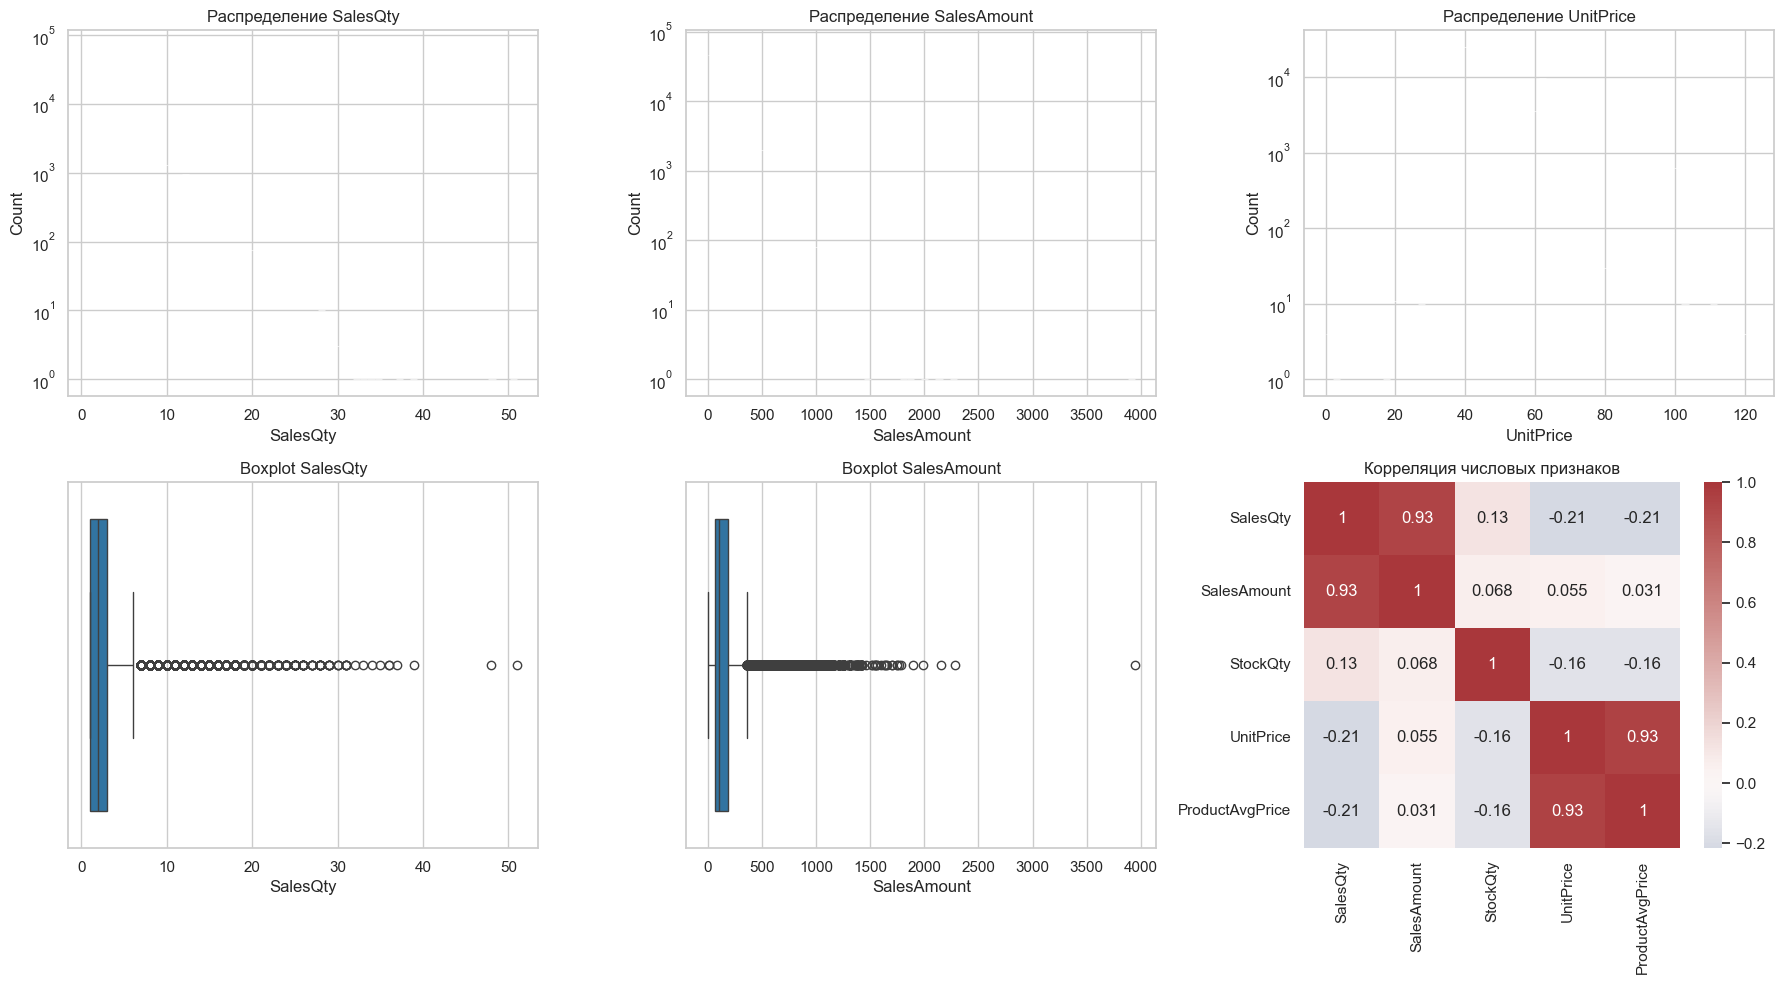

In [9]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
sns.histplot(df_clean['SalesQty'], bins=60, log_scale=(False, True), ax=axes[0, 0])
axes[0, 0].set_title('Распределение SalesQty')
sns.histplot(df_clean['SalesAmount'], bins=60, log_scale=(False, True), ax=axes[0, 1])
axes[0, 1].set_title('Распределение SalesAmount')
sns.histplot(df_clean['UnitPrice'], bins=60, log_scale=(False, True), ax=axes[0, 2])
axes[0, 2].set_title('Распределение UnitPrice')
sns.boxplot(x=df_clean['SalesQty'], ax=axes[1, 0])
axes[1, 0].set_title('Boxplot SalesQty')
sns.boxplot(x=df_clean['SalesAmount'], ax=axes[1, 1])
axes[1, 1].set_title('Boxplot SalesAmount')
sns.heatmap(df_clean[['SalesQty', 'SalesAmount', 'StockQty', 'UnitPrice', 'ProductAvgPrice']].corr(), annot=True, cmap='vlag', center=0, ax=axes[1, 2])
axes[1, 2].set_title('Корреляция числовых признаков')
plt.tight_layout()
plt.show()

**Аналитический комментарий.** Распределения продаж, выручки и цены обычно имеют правостороннюю асимметрию: большинство строк связано с небольшими продажами, а отдельные наблюдения дают крупные значения. Boxplot дополнительно показывает выбросы, которые могут соответствовать крупным магазинам, акциям или аномальным операциям. Корреляционная матрица помогает понять, насколько продажи в штуках связаны с выручкой, запасами и ценой; это важно для выбора признаков и масштабирования.

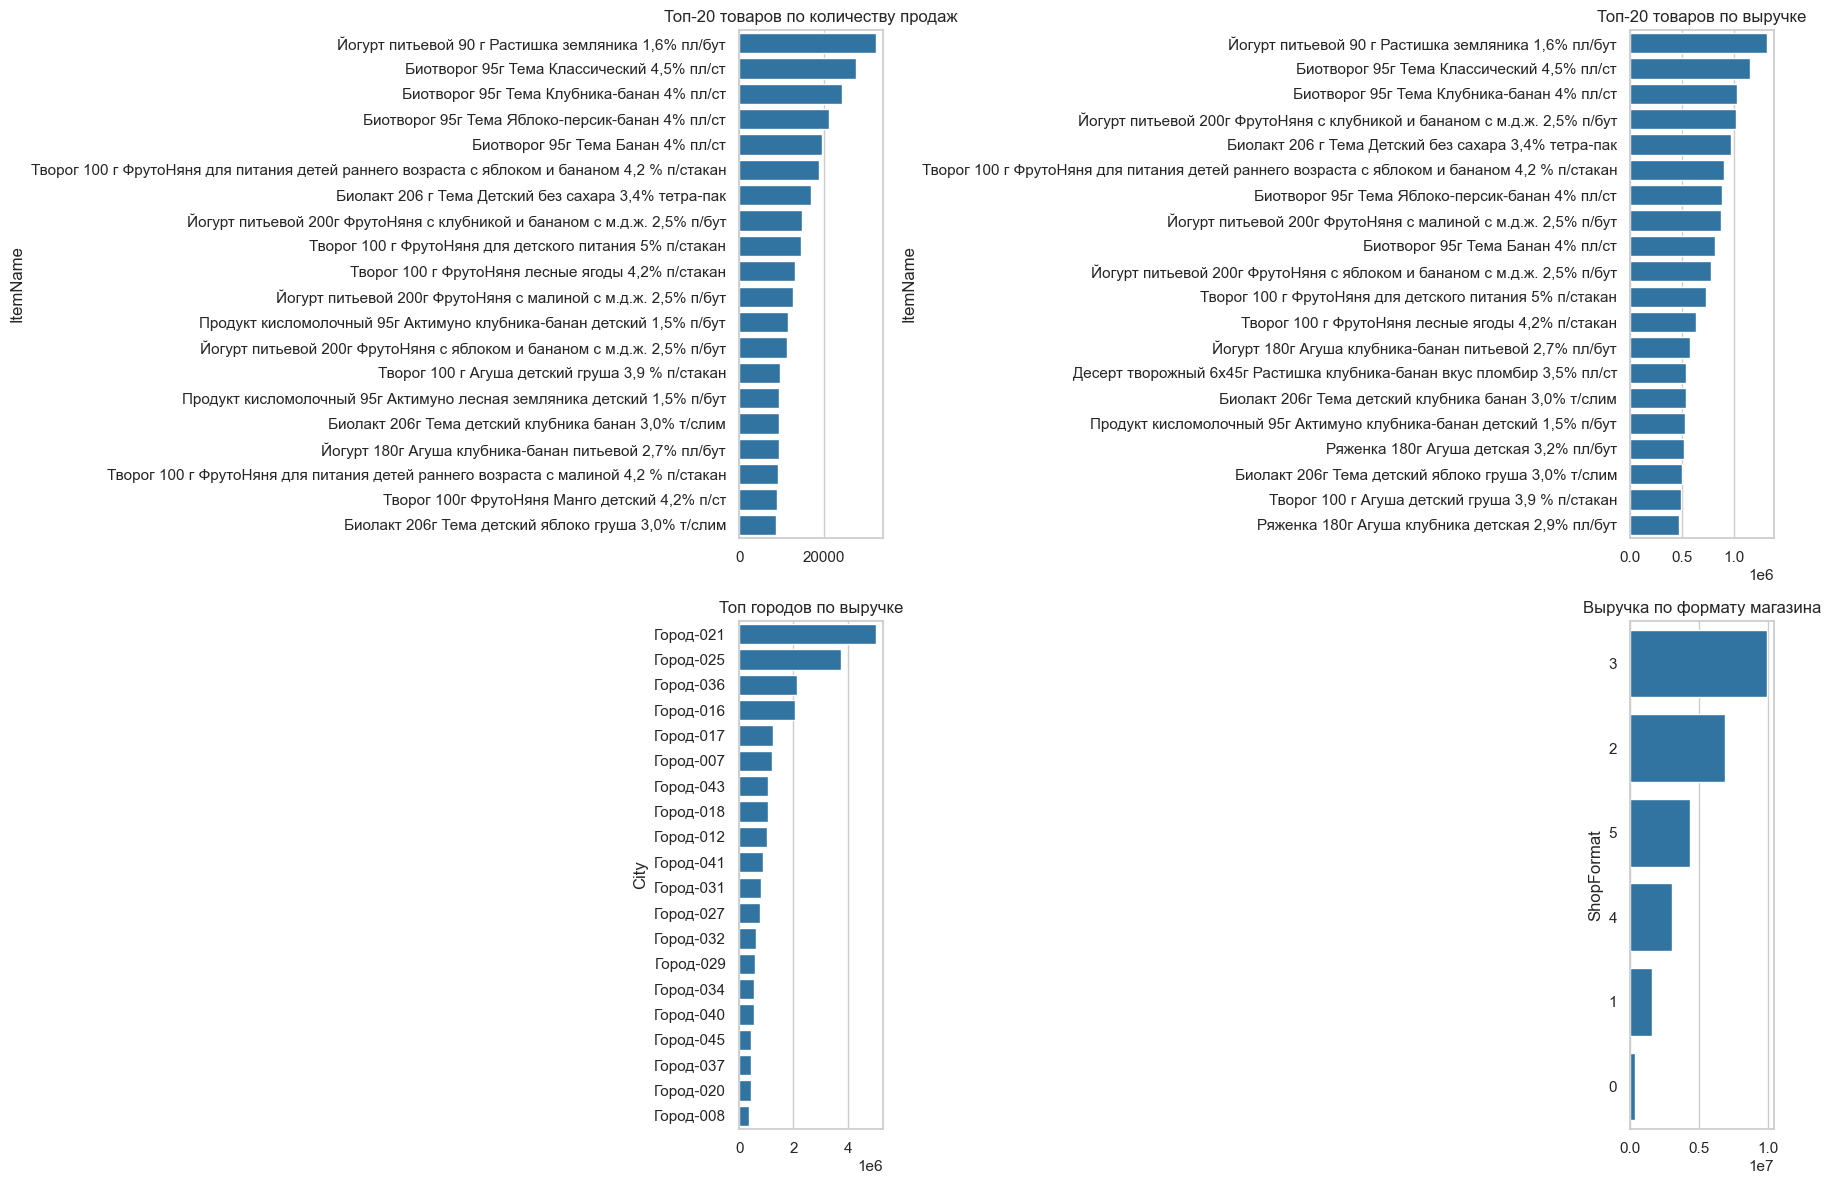

In [10]:
fig, axes = plt.subplots(2, 2, figsize=(18, 12))

top_qty = df_clean.groupby('ItemName')['SalesQty'].sum().sort_values(ascending=False).head(20)
sns.barplot(x=top_qty.values, y=top_qty.index, ax=axes[0, 0])
axes[0, 0].set_title('Топ-20 товаров по количеству продаж')

top_rev = df_clean.groupby('ItemName')['SalesAmount'].sum().sort_values(ascending=False).head(20)
sns.barplot(x=top_rev.values, y=top_rev.index, ax=axes[0, 1])
axes[0, 1].set_title('Топ-20 товаров по выручке')

city_sales = df_clean.groupby('City')['SalesAmount'].sum().sort_values(ascending=False).head(20)
sns.barplot(x=city_sales.values, y=city_sales.index, ax=axes[1, 0])
axes[1, 0].set_title('Топ городов по выручке')

format_sales = df_clean.groupby('ShopFormat')['SalesAmount'].sum().sort_values(ascending=False)
sns.barplot(x=format_sales.values, y=format_sales.index, ax=axes[1, 1])
axes[1, 1].set_title('Выручка по формату магазина')
plt.tight_layout()
plt.show()

**Аналитический комментарий.** Топ товаров показывает, какие позиции формируют основной спрос и выручку в категории. Если топ по штукам и топ по выручке различаются, значит ценовое позиционирование товаров заметно влияет на структуру результата. Продажи по городам и форматам помогают понять, связаны ли будущие кластеры с географией и типом торговой точки, хотя эти поля используются для интерпретации, а не как основные числовые признаки кластеризации.

## 7. Расчёт абсолютных показателей по торговым точкам

In [11]:
store_abs = df_clean.groupby('ShopCode').agg(
    sales_qty_total=('SalesQty', 'sum'),
    revenue_total=('SalesAmount', 'sum'),
    mean_stock_qty=('StockQty', 'mean'),
    median_stock_qty=('StockQty', 'median'),
    max_stock_qty=('StockQty', 'max'),
    unique_products_count=('ItemName', 'nunique'),
    active_days_count=('TransDate', 'nunique'),
    ShopFormat=('ShopFormat', 'first'),
    City=('City', 'first'),
    Region=('Region', 'first'),
).reset_index()

store_abs['avg_revenue_per_unit'] = store_abs['revenue_total'] / store_abs['sales_qty_total']
store_abs['revenue_per_active_day'] = store_abs['revenue_total'] / store_abs['active_days_count'].replace(0, np.nan)
store_abs['sales_qty_per_active_day'] = store_abs['sales_qty_total'] / store_abs['active_days_count'].replace(0, np.nan)
store_abs = store_abs.replace([np.inf, -np.inf], np.nan).fillna(0)

display(store_abs.head())
print('Количество строк в store_abs:', len(store_abs))

,ShopCode,sales_qty_total,revenue_total,mean_stock_qty,median_stock_qty,max_stock_qty,unique_products_count,active_days_count,ShopFormat,City,Region,avg_revenue_per_unit,revenue_per_active_day,sales_qty_per_active_day
0,103,1543.0,80677.96644,9.094946,7.0,43.0,25,174,0,Город-016,Регион-002,52.286433,463.666474,8.867816
1,106,4342.0,217202.13508,13.710843,8.0,183.0,22,184,0,Город-016,Регион-002,50.023523,1180.446386,23.597826
2,1101,4114.0,213950.49522,10.221972,8.0,58.0,54,184,1,Город-036,Регион-007,52.005468,1162.774431,22.358696
3,1110,6627.0,358157.11227,8.300252,6.0,63.0,80,184,1,Город-008,Регион-003,54.045135,1946.506045,36.016304
4,1117,2176.0,106775.58630,8.189922,6.0,38.0,27,178,1,Город-037,Регион-008,49.069663,599.862844,12.224719


Количество строк в store_abs: 68


## 8. Расчёт долевых показателей

In [12]:
TOP_N_PRODUCTS = 30

top_products = (
    df_clean.groupby('ItemName')['SalesQty']
    .sum()
    .sort_values(ascending=False)
    .head(TOP_N_PRODUCTS)
    .index
)

df_clean['ProductGroupForShares'] = np.where(df_clean['ItemName'].isin(top_products), df_clean['ItemName'], 'Other')

product_qty = df_clean.pivot_table(index='ShopCode', columns='ProductGroupForShares', values='SalesQty', aggfunc='sum', fill_value=0)
product_revenue = df_clean.pivot_table(index='ShopCode', columns='ProductGroupForShares', values='SalesAmount', aggfunc='sum', fill_value=0)

product_qty_share = product_qty.div(product_qty.sum(axis=1).replace(0, np.nan), axis=0).fillna(0)
product_revenue_share = product_revenue.div(product_revenue.sum(axis=1).replace(0, np.nan), axis=0).fillna(0)

product_qty_share.columns = ['qty_share_product_' + str(col)[:80] for col in product_qty_share.columns]
product_revenue_share.columns = ['revenue_share_product_' + str(col)[:80] for col in product_revenue_share.columns]

price_qty = df_clean.pivot_table(index='ShopCode', columns='PriceSegment', values='SalesQty', aggfunc='sum', fill_value=0)
price_revenue = df_clean.pivot_table(index='ShopCode', columns='PriceSegment', values='SalesAmount', aggfunc='sum', fill_value=0)

price_qty_share = price_qty.div(price_qty.sum(axis=1).replace(0, np.nan), axis=0).fillna(0)
price_revenue_share = price_revenue.div(price_revenue.sum(axis=1).replace(0, np.nan), axis=0).fillna(0)

price_qty_share.columns = ['qty_share_price_' + str(col) for col in price_qty_share.columns]
price_revenue_share.columns = ['revenue_share_price_' + str(col) for col in price_revenue_share.columns]

share_features = pd.concat([product_qty_share, product_revenue_share, price_qty_share, price_revenue_share], axis=1).reset_index()

display(share_features.head())
print('Долевых признаков:', share_features.shape[1] - 1)

,ShopCode,qty_share_product_Other,"qty_share_product_Биолакт 206 г Тема Детский без сахара 3,4% тетра-пак","qty_share_product_Биолакт 206г Тема детский клубника банан 3,0% т/cлим","qty_share_product_Биолакт 206г Тема детский яблоко груша 3,0% т/cлим",qty_share_product_Биотворог 95г Тема Банан 4% пл/ст,qty_share_product_Биотворог 95г Тема Груша 4% пл/ст,"qty_share_product_Биотворог 95г Тема Классический 4,5% пл/ст",qty_share_product_Биотворог 95г Тема Клубника-банан 4% пл/ст,qty_share_product_Биотворог 95г Тема Яблоко-персик-банан 4% пл/ст,qty_share_product_Йогурт 110 г Растишка клубника густой обогащ. 3% пл/ст,"qty_share_product_Йогурт 180г Агуша клубника-банан питьевой 2,7% пл/бут","qty_share_product_Йогурт 180г Агуша яблоко-груша питьевой 2,7% пл/бут","qty_share_product_Йогурт питьевой 200г ФрутоНяня с клубникой и бананом с м.д.ж. 2,5% п/бут","qty_share_product_Йогурт питьевой 200г ФрутоНяня с малиной с м.д.ж. 2,5% п/бут","qty_share_product_Йогурт питьевой 200г ФрутоНяня с яблоком и бананом с м.д.ж. 2,5% п/бут","qty_share_product_Йогурт питьевой 90 г Растишка земляника 1,6% пл/бут",qty_share_product_Молочный коктейль 200 мл ФрутоНяня для пит. детей раннего возр. с бананом стерил,qty_share_product_Молочный коктейль 200 мл ФрутоНяня для пит. детей раннего возр. с малиной стерил,"qty_share_product_Напиток кисломолочный 100г Имунеле малиновый пломбир forKIDS 1,5% пл/бут",qty_share_product_Продукт кисломолочный 200мл ФрутоНяня Снежок Клубника-Земляника 2% пл/бут,"qty_share_product_Продукт кисломолочный 95г Актимуно клубника-банан детский 1,5% п/бут","qty_share_product_Продукт кисломолочный 95г Актимуно лесная земляника детский 1,5% п/бут","qty_share_product_Ряженка 180г Агуша детская 3,2% пл/бут","qty_share_product_Ряженка 180г Агуша клубника детская 2,9% пл/бут","qty_share_product_Творог 100 г Агуша детский груша 3,9 % п/стакан","qty_share_product_Творог 100 г Агуша детский яблоко-банан 3,9% п/стакан",qty_share_product_Творог 100 г ФрутоНяня для детского питания 5% п/стакан,"qty_share_product_Творог 100 г ФрутоНяня для питания детей раннего возраста с малиной 4,2 % п/стак","qty_share_product_Творог 100 г ФрутоНяня для питания детей раннего возраста с яблоком и бананом 4,","qty_share_product_Творог 100 г ФрутоНяня лесные ягоды 4,2% п/стакан","qty_share_product_Творог 100г ФрутоНяня Манго детский 4,2% п/ст",revenue_share_product_Other,"revenue_share_product_Биолакт 206 г Тема Детский без сахара 3,4% тетра-пак","revenue_share_product_Биолакт 206г Тема детский клубника банан 3,0% т/cлим","revenue_share_product_Биолакт 206г Тема детский яблоко груша 3,0% т/cлим",revenue_share_product_Биотворог 95г Тема Банан 4% пл/ст,revenue_share_product_Биотворог 95г Тема Груша 4% пл/ст,"revenue_share_product_Биотворог 95г Тема Классический 4,5% пл/ст",revenue_share_product_Биотворог 95г Тема Клубника-банан 4% пл/ст,revenue_share_product_Биотворог 95г Тема Яблоко-персик-банан 4% пл/ст,revenue_share_product_Йогурт 110 г Растишка клубника густой обогащ. 3% пл/ст,"revenue_share_product_Йогурт 180г Агуша клубника-банан питьевой 2,7% пл/бут","revenue_share_product_Йогурт 180г Агуша яблоко-груша питьевой 2,7% пл/бут","revenue_share_product_Йогурт питьевой 200г ФрутоНяня с клубникой и бананом с м.д.ж. 2,5% п/бут","revenue_share_product_Йогурт питьевой 200г ФрутоНяня с малиной с м.д.ж. 2,5% п/бут","revenue_share_product_Йогурт питьевой 200г ФрутоНяня с яблоком и бананом с м.д.ж. 2,5% п/бут","revenue_share_product_Йогурт питьевой 90 г Растишка земляника 1,6% пл/бут",revenue_share_product_Молочный коктейль 200 мл ФрутоНяня для пит. детей раннего возр. с бананом стерил,revenue_share_product_Молочный коктейль 200 мл ФрутоНяня для пит. детей раннего возр. с малиной стерил,"revenue_share_product_Напиток кисломолочный 100г Имунеле малиновый пломбир forKIDS 1,5% пл/бут",revenue_share_product_Продукт кисломолочный 200мл ФрутоНяня Снежок Клубника-Земляника 2% пл/бут,"revenue_share_product_Продукт кисломолочный 95г Актимуно клубника-банан детский 1,5% п/бут","revenue

Долевых признаков: 68


**Аналитический комментарий.** Долевые признаки показывают структуру спроса, а не размер магазина. Поэтому они дополняют абсолютные показатели: магазин с небольшой выручкой может быть похож на крупный магазин по ассортиментной структуре, но отличаться масштабом продаж.

## 9. Формирование матрицы признаков

In [13]:
store_features = store_abs.merge(share_features, on='ShopCode', how='left').fillna(0)

absolute_features = [
    'sales_qty_total',
    'revenue_total',
    'avg_revenue_per_unit',
    'mean_stock_qty',
    'median_stock_qty',
    'max_stock_qty',
    'unique_products_count',
    'active_days_count',
    'revenue_per_active_day',
    'sales_qty_per_active_day',
]
share_feature_cols = [c for c in store_features.columns if c.startswith(('qty_share_', 'revenue_share_'))]
metadata_cols = ['ShopCode', 'ShopFormat', 'City', 'Region']

for col in absolute_features + share_feature_cols:
    store_features[col] = pd.to_numeric(store_features[col], errors='coerce')

store_features[absolute_features + share_feature_cols] = store_features[absolute_features + share_feature_cols].replace([np.inf, -np.inf], np.nan).fillna(0)
store_features.to_csv(STORE_FEATURES_PATH, index=False, encoding='utf-8-sig')
print(f'Сохранено: {STORE_FEATURES_PATH}')
print('Размер матрицы магазинов:', store_features.shape)
display(store_features.head())

Сохранено: store_feature_matrix.csv
Размер матрицы магазинов: (68, 82)


,ShopCode,sales_qty_total,revenue_total,mean_stock_qty,median_stock_qty,max_stock_qty,unique_products_count,active_days_count,ShopFormat,City,Region,avg_revenue_per_unit,revenue_per_active_day,sales_qty_per_active_day,qty_share_product_Other,"qty_share_product_Биолакт 206 г Тема Детский без сахара 3,4% тетра-пак","qty_share_product_Биолакт 206г Тема детский клубника банан 3,0% т/cлим","qty_share_product_Биолакт 206г Тема детский яблоко груша 3,0% т/cлим",qty_share_product_Биотворог 95г Тема Банан 4% пл/ст,qty_share_product_Биотворог 95г Тема Груша 4% пл/ст,"qty_share_product_Биотворог 95г Тема Классический 4,5% пл/ст",qty_share_product_Биотворог 95г Тема Клубника-банан 4% пл/ст,qty_share_product_Биотворог 95г Тема Яблоко-персик-банан 4% пл/ст,qty_share_product_Йогурт 110 г Растишка клубника густой обогащ. 3% пл/ст,"qty_share_product_Йогурт 180г Агуша клубника-банан питьевой 2,7% пл/бут","qty_share_product_Йогурт 180г Агуша яблоко-груша питьевой 2,7% пл/бут","qty_share_product_Йогурт питьевой 200г ФрутоНяня с клубникой и бананом с м.д.ж. 2,5% п/бут","qty_share_product_Йогурт питьевой 200г ФрутоНяня с малиной с м.д.ж. 2,5% п/бут","qty_share_product_Йогурт питьевой 200г ФрутоНяня с яблоком и бананом с м.д.ж. 2,5% п/бут","qty_share_product_Йогурт питьевой 90 г Растишка земляника 1,6% пл/бут",qty_share_product_Молочный коктейль 200 мл ФрутоНяня для пит. детей раннего возр. с бананом стерил,qty_share_product_Молочный коктейль 200 мл ФрутоНяня для пит. детей раннего возр. с малиной стерил,"qty_share_product_Напиток кисломолочный 100г Имунеле малиновый пломбир forKIDS 1,5% пл/бут",qty_share_product_Продукт кисломолочный 200мл ФрутоНяня Снежок Клубника-Земляника 2% пл/бут,"qty_share_product_Продукт кисломолочный 95г Актимуно клубника-банан детский 1,5% п/бут","qty_share_product_Продукт кисломолочный 95г Актимуно лесная земляника детский 1,5% п/бут","qty_share_product_Ряженка 180г Агуша детская 3,2% пл/бут","qty_share_product_Ряженка 180г Агуша клубника детская 2,9% пл/бут","qty_share_product_Творог 100 г Агуша детский груша 3,9 % п/стакан","qty_share_product_Творог 100 г Агуша детский яблоко-банан 3,9% п/стакан",qty_share_product_Творог 100 г ФрутоНяня для детского питания 5% п/стакан,"qty_share_product_Творог 100 г ФрутоНяня для питания детей раннего возраста с малиной 4,2 % п/стак","qty_share_product_Творог 100 г ФрутоНяня для питания детей раннего возраста с яблоком и бананом 4,","qty_share_product_Творог 100 г ФрутоНяня лесные ягоды 4,2% п/стакан","qty_share_product_Творог 100г ФрутоНяня Манго детский 4,2% п/ст",revenue_share_product_Other,"revenue_share_product_Биолакт 206 г Тема Детский без сахара 3,4% тетра-пак","revenue_share_product_Биолакт 206г Тема детский клубника банан 3,0% т/cлим","revenue_share_product_Биолакт 206г Тема детский яблоко груша 3,0% т/cлим",revenue_share_product_Биотворог 95г Тема Банан 4% пл/ст,revenue_share_product_Биотворог 95г Тема Груша 4% пл/ст,"revenue_share_product_Биотворог 95г Тема Классический 4,5% пл/ст",revenue_share_product_Биотворог 95г Тема Клубника-банан 4% пл/ст,revenue_share_product_Биотворог 95г Тема Яблоко-персик-банан 4% пл/ст,revenue_share_product_Йогурт 110 г Растишка клубника густой обогащ. 3% пл/ст,"revenue_share_product_Йогурт 180г Агуша клубника-банан питьевой 2,7% пл/бут","revenue_share_product_Йогурт 180г Агуша яблоко-груша питьевой 2,7% пл/бут","revenue_share_product_Йогурт питьевой 200г ФрутоНяня с клубникой и бананом с м.д.ж. 2,5% п/бут","revenue_share_product_Йогурт питьевой 200г ФрутоНяня с малиной с м.д.ж. 2,5% п/бут","revenue_share_product_Йогурт питьевой 200г ФрутоНяня с яблоком и бананом с м.д.ж. 2,5% п/бут","revenue_share_product_Йогурт питьевой 90 г Растишка земляника 1,6% пл/бут",revenue_share_product_Молочный коктейль 200 мл ФрутоНяня для пит. детей раннего возр. с бананом стерил,revenue_share_product_Молочный коктейль 200 мл ФрутоНяня для пит. детей раннего возр. с малиной стерил,"revenue_share_product_Напиток кисломолочный 100г Имунеле малиновый пломбир forKIDS 1,

## 10. Сравнение вариантов признакового пространства

In [14]:
def make_weighted_matrix(df_features, absolute_cols, share_cols):
    abs_scaled = StandardScaler().fit_transform(df_features[absolute_cols]) if absolute_cols else np.empty((len(df_features), 0))
    product_cols = [c for c in share_cols if '_product_' in c]
    price_cols = [c for c in share_cols if '_price_' in c]
    product_scaled = StandardScaler().fit_transform(df_features[product_cols]) if product_cols else np.empty((len(df_features), 0))
    price_scaled = StandardScaler().fit_transform(df_features[price_cols]) if price_cols else np.empty((len(df_features), 0))
    return np.hstack([abs_scaled * 0.5, product_scaled * 0.3, price_scaled * 0.2])


feature_variants = {
    'A_absolute_only': absolute_features,
    'B_share_only': share_feature_cols,
    'C_combined': absolute_features + share_feature_cols,
}

weighted_matrix = make_weighted_matrix(store_features, absolute_features, share_feature_cols)

variant_results = []
for variant_name, cols in feature_variants.items():
    X_variant = StandardScaler().fit_transform(store_features[cols])
    max_k = min(10, len(store_features) - 1)
    for k in range(2, max_k + 1):
        labels = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=20).fit_predict(X_variant)
        variant_results.append({
            'Variant': variant_name,
            'k': k,
            'Silhouette': silhouette_score(X_variant, labels),
            'Calinski-Harabasz': calinski_harabasz_score(X_variant, labels),
            'Davies-Bouldin': davies_bouldin_score(X_variant, labels),
        })

for k in range(2, min(10, len(store_features) - 1) + 1):
    labels = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=20).fit_predict(weighted_matrix)
    variant_results.append({
        'Variant': 'D_weighted_combined',
        'k': k,
        'Silhouette': silhouette_score(weighted_matrix, labels),
        'Calinski-Harabasz': calinski_harabasz_score(weighted_matrix, labels),
        'Davies-Bouldin': davies_bouldin_score(weighted_matrix, labels),
    })

variant_results_df = pd.DataFrame(variant_results)
display(variant_results_df.sort_values(['Silhouette', 'Calinski-Harabasz'], ascending=[False, False]).head(15))

,Variant,k,Silhouette,Calinski-Harabasz,Davies-Bouldin
1,A_absolute_only,3,0.436179,33.651310,0.824105
0,A_absolute_only,2,0.409019,33.670327,0.903899
2,A_absolute_only,4,0.377730,40.476937,0.911257
3,A_absolute_only,5,0.372020,41.514804,0.897733
8,A_absolute_only,10,0.341018,46.315881,0.720088
6,A_absolute_only,8,0.340783,44.743081,0.714716
7,A_absolute_only,9,0.339421,45.424231,0.709703
12,B_share_only,5,0.332279,19.722455,0.960245
11,B_share_only,4,0.325338,22.292868,1.127341
9,B_share_only,2,0.314782,25.186889,1.530397


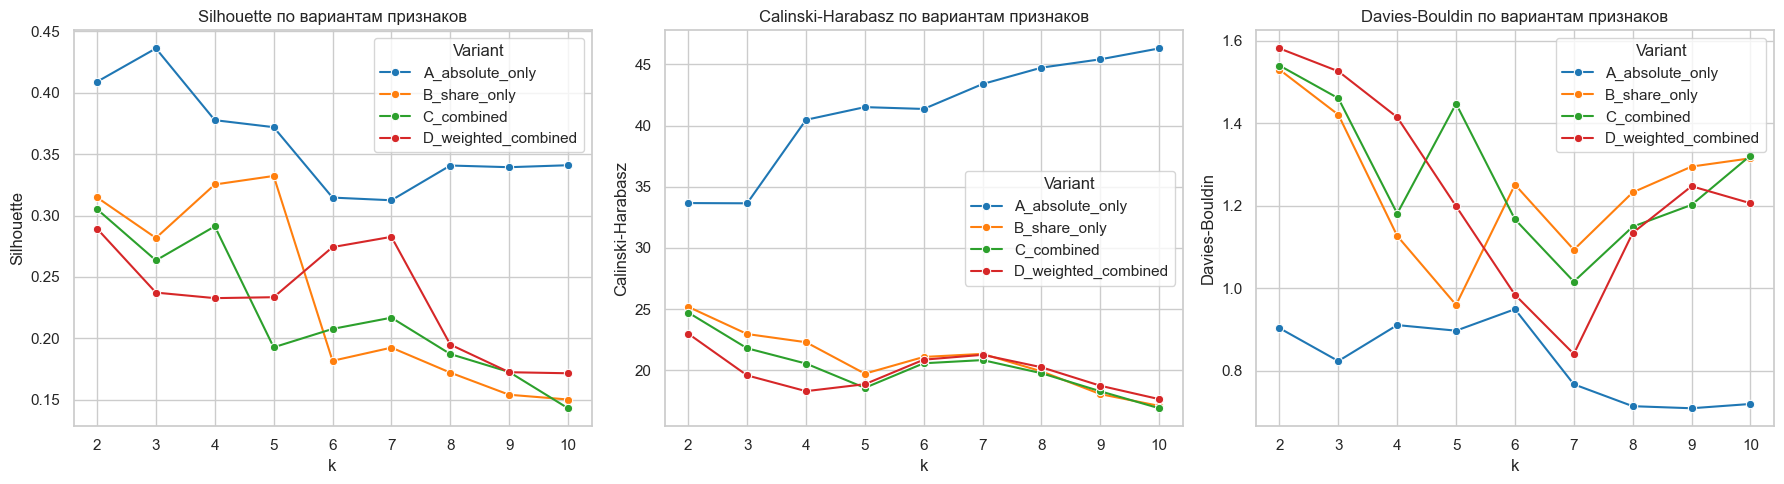

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
sns.lineplot(data=variant_results_df, x='k', y='Silhouette', hue='Variant', marker='o', ax=axes[0])
sns.lineplot(data=variant_results_df, x='k', y='Calinski-Harabasz', hue='Variant', marker='o', ax=axes[1])
sns.lineplot(data=variant_results_df, x='k', y='Davies-Bouldin', hue='Variant', marker='o', ax=axes[2])
axes[0].set_title('Silhouette по вариантам признаков')
axes[1].set_title('Calinski-Harabasz по вариантам признаков')
axes[2].set_title('Davies-Bouldin по вариантам признаков')
plt.tight_layout()
plt.show()

**Аналитический комментарий.** Графики сравнивают, насколько хорошо k-means разделяет магазины при разных наборах признаков. Абсолютные признаки сильнее отражают масштаб торговой точки, долевые признаки - структуру спроса, а комбинированные варианты позволяют учитывать обе стороны. Для дальнейшего анализа выбран взвешенный комбинированный вариант: он сохраняет влияние размера магазина, но снижает риск того, что крупные магазины полностью зададут геометрию кластеров.

## 11. Масштабирование данных

In [16]:
MAIN_FEATURE_SET = 'D_weighted_combined'
X_main_raw = weighted_matrix

scalers = {
    'StandardScaler': StandardScaler(),
    'MinMaxScaler': MinMaxScaler(),
    'RobustScaler': RobustScaler(),
}

scaler_results = []
scaled_matrices = {}
max_k = min(10, len(store_features) - 1)
for scaler_name, scaler in scalers.items():
    X_scaled = scaler.fit_transform(X_main_raw)
    scaled_matrices[scaler_name] = X_scaled
    for k in range(2, max_k + 1):
        labels = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=20).fit_predict(X_scaled)
        scaler_results.append({
            'Scaler': scaler_name,
            'k': k,
            'Silhouette': silhouette_score(X_scaled, labels),
            'Calinski-Harabasz': calinski_harabasz_score(X_scaled, labels),
            'Davies-Bouldin': davies_bouldin_score(X_scaled, labels),
        })

scaler_results_df = pd.DataFrame(scaler_results)
display(scaler_results_df.sort_values(['Silhouette', 'Calinski-Harabasz'], ascending=[False, False]).head(15))

,Scaler,k,Silhouette,Calinski-Harabasz,Davies-Bouldin
18,RobustScaler,2,0.878715,142.284307,0.074793
19,RobustScaler,3,0.468930,113.404765,0.832884
9,MinMaxScaler,2,0.320510,31.596856,1.383500
11,MinMaxScaler,4,0.319429,23.784535,1.081089
0,StandardScaler,2,0.305216,24.717890,1.540287
10,MinMaxScaler,3,0.293238,27.453125,1.318892
2,StandardScaler,4,0.291247,20.547719,1.181529
1,StandardScaler,3,0.263514,21.797672,1.460966
21,RobustScaler,5,0.262046,88.410384,0.992156
23,RobustScaler,7,0.242910,80.613467,0.887210


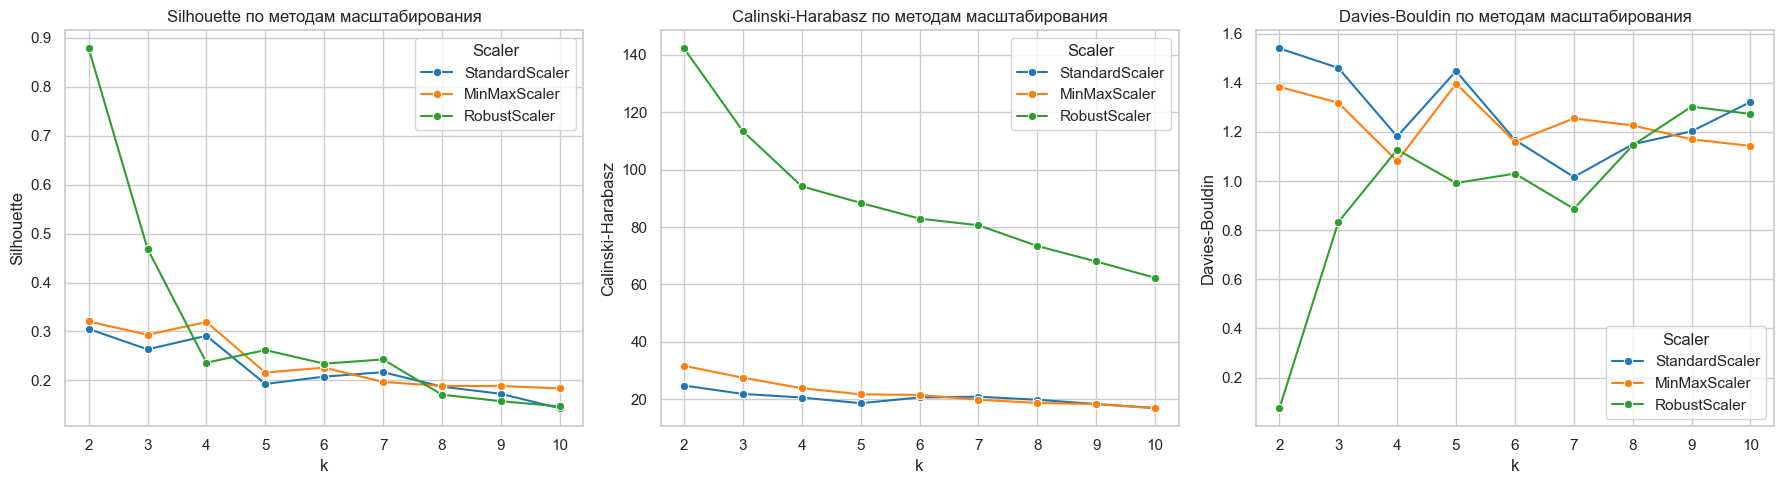

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
sns.lineplot(data=scaler_results_df, x='k', y='Silhouette', hue='Scaler', marker='o', ax=axes[0])
sns.lineplot(data=scaler_results_df, x='k', y='Calinski-Harabasz', hue='Scaler', marker='o', ax=axes[1])
sns.lineplot(data=scaler_results_df, x='k', y='Davies-Bouldin', hue='Scaler', marker='o', ax=axes[2])
axes[0].set_title('Silhouette по методам масштабирования')
axes[1].set_title('Calinski-Harabasz по методам масштабирования')
axes[2].set_title('Davies-Bouldin по методам масштабирования')
plt.tight_layout()
plt.show()

**Аналитический комментарий.** Масштабирование необходимо, потому что выручка, количество продаж, запасы и доли имеют разные единицы измерения. Если метрики для `RobustScaler` лучше или сопоставимы, его удобно использовать при наличии выбросов: он меньше зависит от экстремально крупных магазинов. Если лидирует `StandardScaler`, значит выбросы не настолько искажают итоговую геометрию признаков.

In [18]:
best_scaler_name = scaler_results_df.sort_values(['Silhouette', 'Calinski-Harabasz'], ascending=[False, False]).iloc[0]['Scaler']
X_main = scaled_matrices[best_scaler_name]
print('Выбранный scaler:', best_scaler_name)

Выбранный scaler: RobustScaler


## 12. k-means: подбор количества кластеров

In [19]:
def evaluate_clustering(X, labels, algorithm, params, noise_label=-1):
    """Возвращает число кластеров, шум и метрики качества кластеризации."""
    labels = np.asarray(labels)
    non_noise_mask = labels != noise_label
    unique_non_noise = sorted(set(labels[non_noise_mask]))
    n_clusters = len(unique_non_noise)
    noise_count = int((labels == noise_label).sum())

    result = {
        'Algorithm': algorithm,
        'Parameters': str(params),
        'Clusters': n_clusters,
        'Noise points': noise_count,
        'Silhouette': np.nan,
        'Calinski-Harabasz': np.nan,
        'Davies-Bouldin': np.nan,
        'Comment': '',
    }

    if n_clusters < 2 or non_noise_mask.sum() <= n_clusters:
        result['Comment'] = 'Метрики не рассчитаны: меньше двух кластеров или слишком мало точек без шума.'
        return result

    X_eval = X[non_noise_mask]
    labels_eval = labels[non_noise_mask]
    result['Silhouette'] = silhouette_score(X_eval, labels_eval)
    result['Calinski-Harabasz'] = calinski_harabasz_score(X_eval, labels_eval)
    result['Davies-Bouldin'] = davies_bouldin_score(X_eval, labels_eval)
    result['Comment'] = 'Метрики рассчитаны по точкам без шума.' if noise_count else 'Метрики рассчитаны по всем магазинам.'
    return result


k_values = range(2, min(10, len(store_features) - 1) + 1)
kmeans_rows = []
kmeans_models = {}

for k in k_values:
    model = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=20)
    labels = model.fit_predict(X_main)
    row = evaluate_clustering(X_main, labels, 'KMeans', {'k': k, 'scaler': best_scaler_name})
    row['Inertia'] = model.inertia_
    kmeans_rows.append(row)
    kmeans_models[k] = {'model': model, 'labels': labels}

kmeans_metrics = pd.DataFrame(kmeans_rows)
display(kmeans_metrics)

,Algorithm,Parameters,Clusters,Noise points,Silhouette,Calinski-Harabasz,Davies-Bouldin,Comment,Inertia
0,KMeans,"{'k': 2, 'scaler': 'RobustScaler'}",2,0,0.878715,142.284307,0.074793,Метрики рассчитаны по всем магазинам.,4326.394598
1,KMeans,"{'k': 3, 'scaler': 'RobustScaler'}",3,0,0.468930,113.404765,0.832884,Метрики рассчитаны по всем магазинам.,3041.253552
2,KMeans,"{'k': 4, 'scaler': 'RobustScaler'}",4,0,0.236238,94.184904,1.127976,Метрики рассчитаны по всем магазинам.,2521.429956
3,KMeans,"{'k': 5, 'scaler': 'RobustScaler'}",5,0,0.262046,88.410384,0.992156,Метрики рассчитаны по всем магазинам.,2064.508750
4,KMeans,"{'k': 6, 'scaler': 'RobustScaler'}",6,0,0.234214,82.927849,1.030393,Метрики рассчитаны по всем магазинам.,1775.990473
5,KMeans,"{'k': 7, 'scaler': 'RobustScaler'}",7,0,0.242910,80.613467,0.887210,Метрики рассчитаны по всем магазинам.,1529.066982
6,KMeans,"{'k': 8, 'scaler': 'RobustScaler'}",8,0,0.170798,73.387294,1.145670,Метрики рассчитаны по всем магазинам.,1427.896648
7,KMeans,"{'k': 9, 'scaler': 'RobustScaler'}",9,0,0.157564,67.985632,1.303060,Метрики рассчитаны по всем магазинам.,1336.153132
8,KMeans,"{'k': 10, 'scaler': 'RobustScaler'}",10,0,0.146859,62.293504,1.273640,Метрики рассчитаны по всем магазинам.,1280.052137


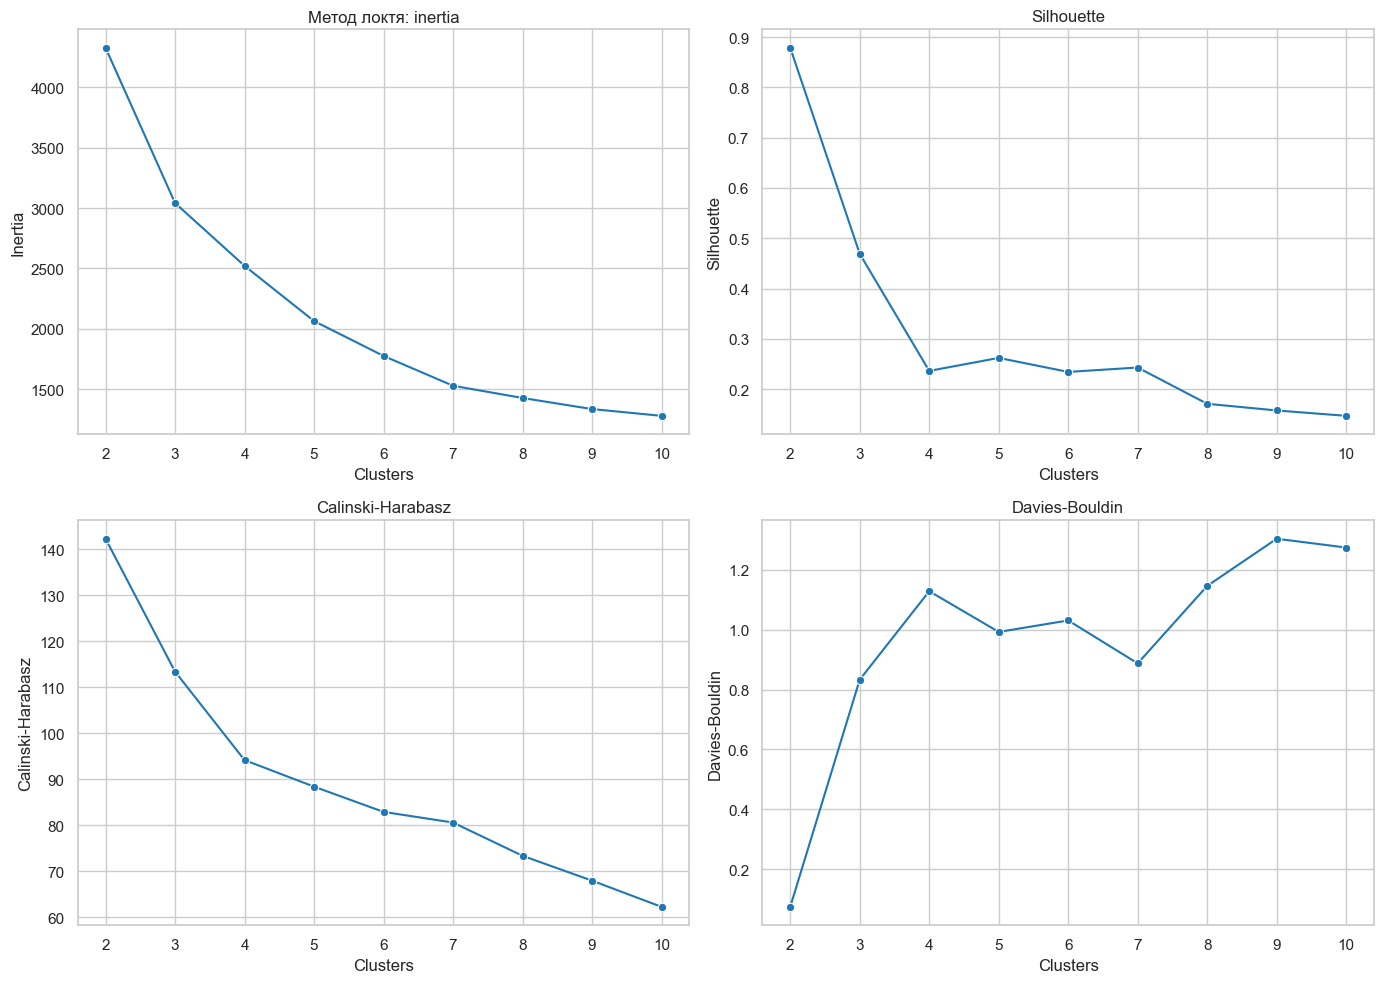

k по методу KneeLocator: None


In [20]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
sns.lineplot(data=kmeans_metrics, x='Clusters', y='Inertia', marker='o', ax=axes[0, 0])
axes[0, 0].set_title('Метод локтя: inertia')

knee_k = None
if KNEED_AVAILABLE and kmeans_metrics['Inertia'].notna().sum() >= 3:
    kl = KneeLocator(kmeans_metrics['Clusters'], kmeans_metrics['Inertia'], curve='convex', direction='decreasing')
    knee_k = kl.knee
    if knee_k is not None:
        axes[0, 0].axvline(knee_k, color='red', linestyle='--', label=f'knee={knee_k}')
        axes[0, 0].legend()

sns.lineplot(data=kmeans_metrics, x='Clusters', y='Silhouette', marker='o', ax=axes[0, 1])
axes[0, 1].set_title('Silhouette')
sns.lineplot(data=kmeans_metrics, x='Clusters', y='Calinski-Harabasz', marker='o', ax=axes[1, 0])
axes[1, 0].set_title('Calinski-Harabasz')
sns.lineplot(data=kmeans_metrics, x='Clusters', y='Davies-Bouldin', marker='o', ax=axes[1, 1])
axes[1, 1].set_title('Davies-Bouldin')
plt.tight_layout()
plt.show()

print('k по методу KneeLocator:', knee_k)

**Аналитический комментарий.** Метод локтя показывает, после какого количества кластеров снижение внутрикластерной суммы квадратов становится менее существенным. Silhouette оценивает отделимость кластеров, Calinski-Harabasz растёт при более плотных и разделённых группах, а Davies-Bouldin лучше при меньших значениях. Если показатели предлагают разные `k`, итоговый выбор должен учитывать не только максимум метрики, но и бизнес-интерпретируемость сегментов.

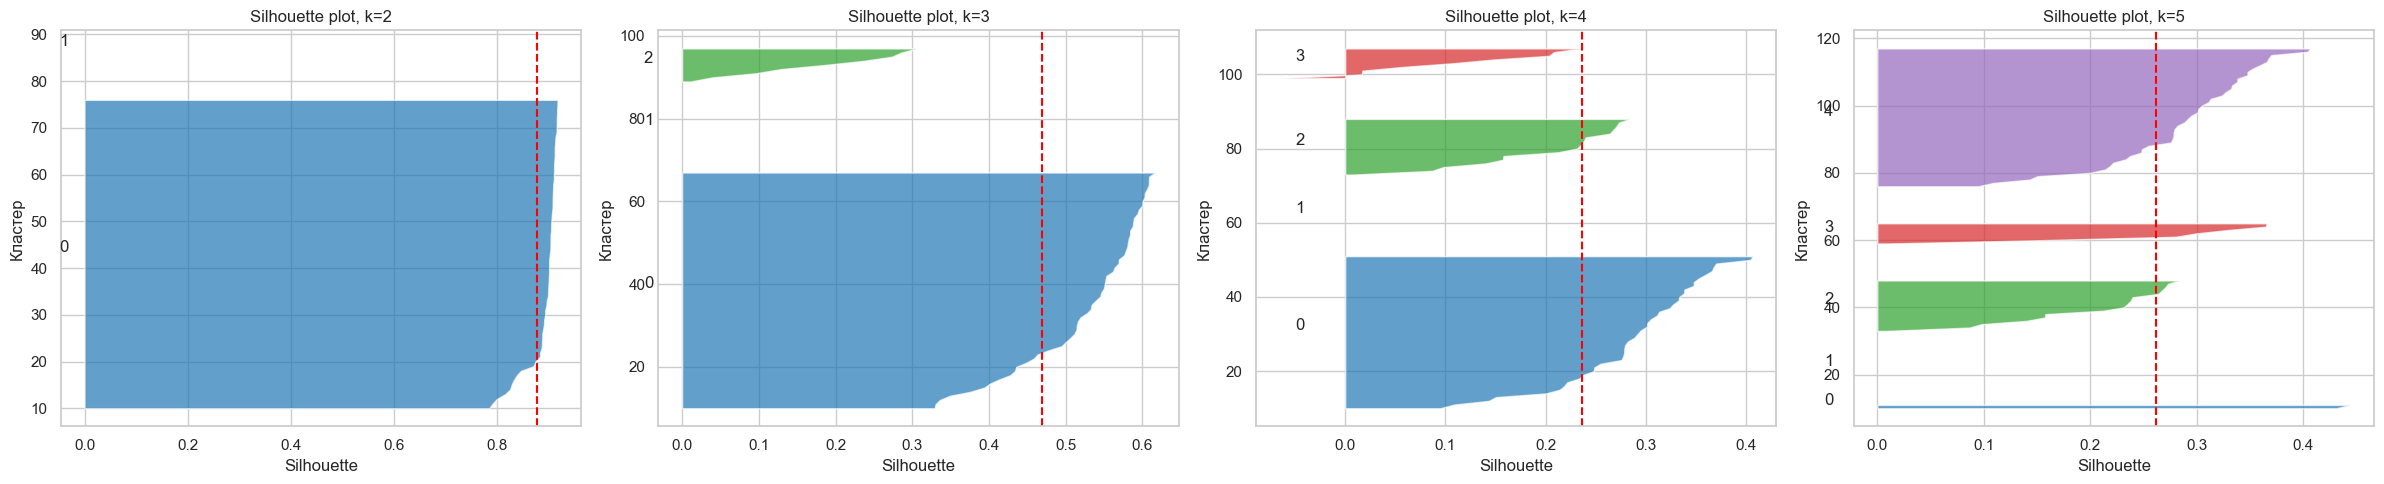

In [21]:
def plot_silhouette_for_k_values(X, model_dict, candidate_k):
    valid_k = [k for k in candidate_k if k in model_dict]
    if not valid_k:
        print('Нет допустимых k для silhouette plot')
        return
    fig, axes = plt.subplots(1, len(valid_k), figsize=(6 * len(valid_k), 5), squeeze=False)
    for ax, k in zip(axes.ravel(), valid_k):
        labels = model_dict[k]['labels']
        sample_values = silhouette_samples(X, labels)
        y_lower = 10
        for cluster_id in sorted(np.unique(labels)):
            values = sample_values[labels == cluster_id]
            values.sort()
            y_upper = y_lower + len(values)
            ax.fill_betweenx(np.arange(y_lower, y_upper), 0, values, alpha=0.7)
            ax.text(-0.05, y_lower + 0.5 * len(values), str(cluster_id))
            y_lower = y_upper + 10
        ax.axvline(np.mean(sample_values), color='red', linestyle='--')
        ax.set_title(f'Silhouette plot, k={k}')
        ax.set_xlabel('Silhouette')
        ax.set_ylabel('Кластер')
    plt.tight_layout()
    plt.show()


interesting_k = sorted(set([3, 4, 5, int(kmeans_metrics.sort_values('Silhouette', ascending=False).iloc[0]['Clusters'])]))
plot_silhouette_for_k_values(X_main, kmeans_models, interesting_k[:4])

**Аналитический комментарий.** Silhouette-графики помогают увидеть не только средний показатель, но и качество каждого отдельного кластера. Узкие или отрицательные участки говорят о магазинах на границах сегментов. Если при большем `k` появляются очень маленькие и плохо отделённые группы, такой вариант может быть менее удобен для бизнес-использования, даже если одна из метрик немного улучшается.

In [22]:
best_silhouette_k = int(kmeans_metrics.sort_values('Silhouette', ascending=False).iloc[0]['Clusters'])
if knee_k is not None and knee_k in kmeans_models:
    final_k = int(knee_k)
elif best_silhouette_k in [3, 4, 5, 6]:
    final_k = best_silhouette_k
else:
    final_k = 4 if 4 in kmeans_models else best_silhouette_k

print('Финально выбранное k для k-means:', final_k)

Финально выбранное k для k-means: 4


## 13. k-means: финальная модель

In [23]:
kmeans_final = KMeans(n_clusters=final_k, random_state=RANDOM_STATE, n_init=20)
store_features['cluster_kmeans'] = kmeans_final.fit_predict(X_main)
kmeans_final_metrics = evaluate_clustering(X_main, store_features['cluster_kmeans'], 'KMeans', {'k': final_k, 'scaler': best_scaler_name})
display(pd.DataFrame([kmeans_final_metrics]))
display(store_features['cluster_kmeans'].value_counts().sort_index().rename('stores_count'))

,Algorithm,Parameters,Clusters,Noise points,Silhouette,Calinski-Harabasz,Davies-Bouldin,Comment
0,KMeans,"{'k': 4, 'scaler': 'RobustScaler'}",4,0,0.236238,94.184904,1.127976,Метрики рассчитаны по всем магазинам.


cluster_kmeans
0    42
1     1
2    16
3     9
Name: stores_count, dtype: int64

## 14. Иерархическая кластеризация

In [24]:
hier_rows = []
hier_labels = {}
linkage_methods = ['ward', 'complete', 'average']
hier_k_values = range(2, min(7, len(store_features) - 1) + 1)

for method in linkage_methods:
    for n_clusters in hier_k_values:
        model = AgglomerativeClustering(n_clusters=n_clusters, linkage=method)
        labels = model.fit_predict(X_main)
        row = evaluate_clustering(X_main, labels, 'AgglomerativeClustering', {'linkage': method, 'n_clusters': n_clusters})
        hier_rows.append(row)
        hier_labels[(method, n_clusters)] = labels

hier_metrics = pd.DataFrame(hier_rows)
display(hier_metrics.sort_values(['Silhouette', 'Calinski-Harabasz'], ascending=[False, False]).head(15))

,Algorithm,Parameters,Clusters,Noise points,Silhouette,Calinski-Harabasz,Davies-Bouldin,Comment
0,AgglomerativeClustering,"{'linkage': 'ward', 'n_clusters': 2}",2,0,0.878715,142.284307,0.074793,Метрики рассчитаны по всем магазинам.
6,AgglomerativeClustering,"{'linkage': 'complete', 'n_clusters': 2}",2,0,0.878715,142.284307,0.074793,Метрики рассчитаны по всем магазинам.
12,AgglomerativeClustering,"{'linkage': 'average', 'n_clusters': 2}",2,0,0.878715,142.284307,0.074793,Метрики рассчитаны по всем магазинам.
7,AgglomerativeClustering,"{'linkage': 'complete', 'n_clusters': 3}",3,0,0.485778,86.355602,0.491462,Метрики рассчитаны по всем магазинам.
13,AgglomerativeClustering,"{'linkage': 'average', 'n_clusters': 3}",3,0,0.485778,86.355602,0.491462,Метрики рассчитаны по всем магазинам.
8,AgglomerativeClustering,"{'linkage': 'complete', 'n_clusters': 4}",4,0,0.475162,91.373202,0.685212,Метрики рассчитаны по всем магазинам.
14,AgglomerativeClustering,"{'linkage': 'average', 'n_clusters': 4}",4,0,0.472709,64.017762,0.454702,Метрики рассчитаны по всем магазинам.
9,AgglomerativeClustering,"{'linkage': 'complete', 'n_clusters': 5}",5,0,0.469019,76.249320,0.530097,Метрики рассчитаны по всем магазинам.
15,AgglomerativeClustering,"{'linkage': 'average', 'n_clusters': 5}",5,0,0.469019,76.249320,0.530097,Метрики рассчитаны по всем магазинам.
1,AgglomerativeClustering,"{'linkage': 'ward', 'n_clusters': 3}",3,0,0.468930,113.404765,0.832884,Метрики рассчитаны по всем магазинам.


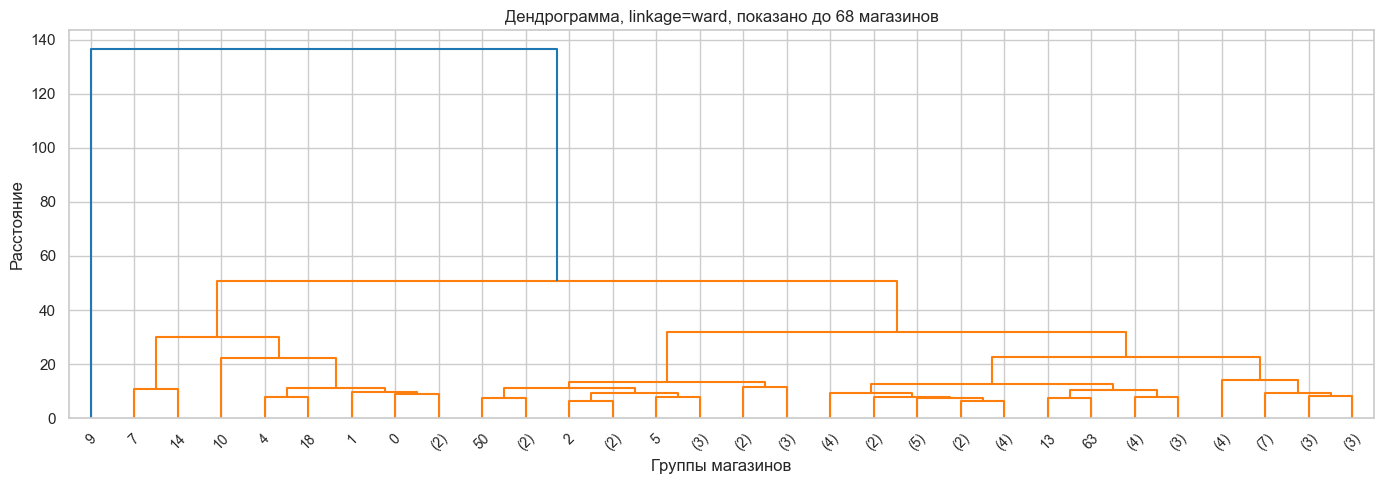

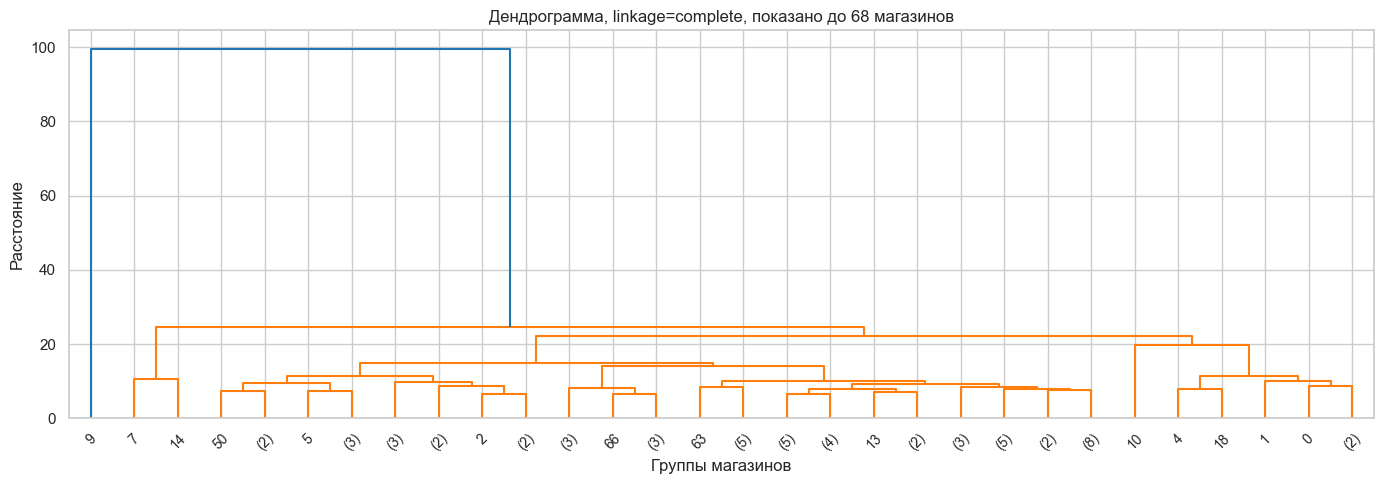

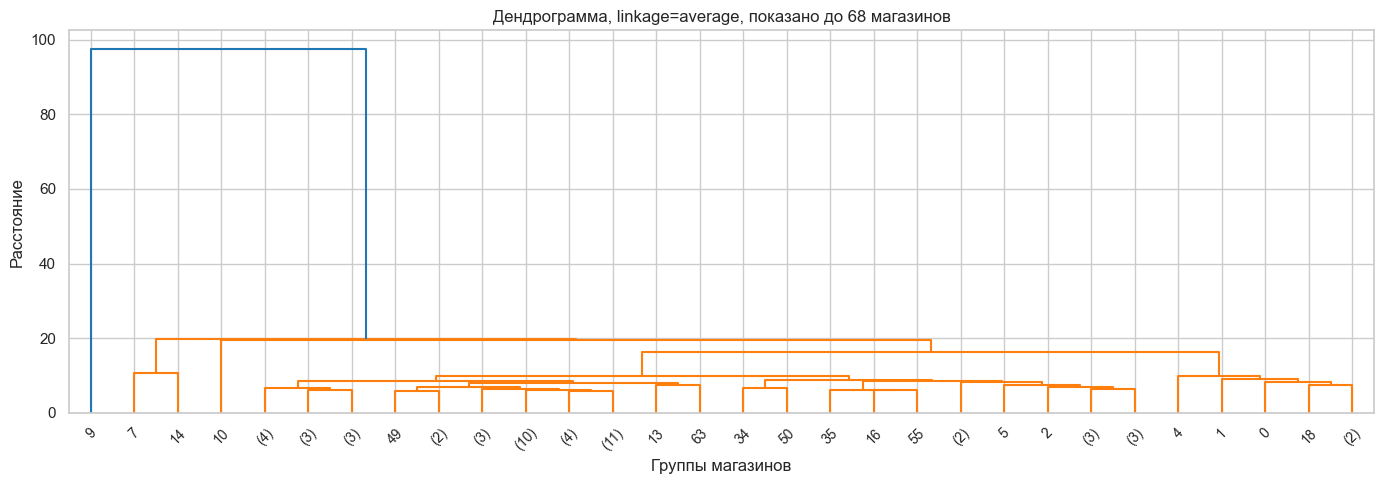

In [25]:
for method in linkage_methods:
    plt.figure(figsize=(14, 5))
    sample_size = min(200, len(store_features))
    X_dendro = X_main[:sample_size]
    Z = linkage(X_dendro, method=method)
    dendrogram(Z, truncate_mode='lastp', p=30, leaf_rotation=45, leaf_font_size=10)
    plt.title(f'Дендрограмма, linkage={method}, показано до {sample_size} магазинов')
    plt.xlabel('Группы магазинов')
    plt.ylabel('Расстояние')
    plt.tight_layout()
    plt.show()

**Аналитический комментарий.** Дендрограммы показывают вложенную структуру похожести магазинов. Большие вертикальные разрывы перед объединением ветвей указывают на потенциально естественное число кластеров. Если дерево слишком плотное, усечённый вид используется для чтения общей структуры, а не для точной идентификации каждого магазина.

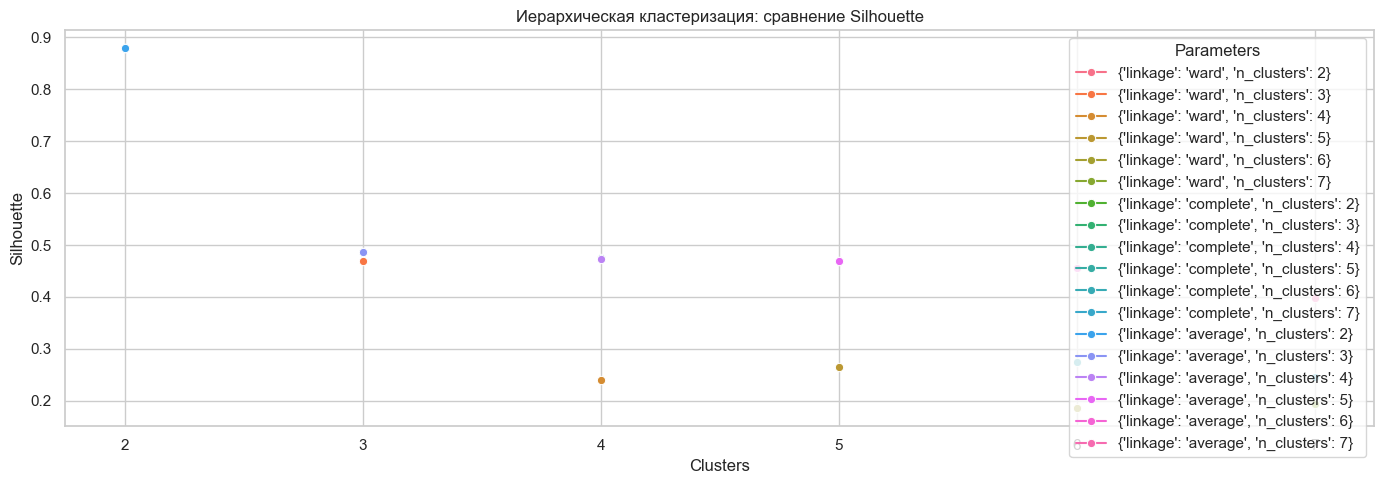

In [26]:
plt.figure(figsize=(14, 5))
sns.lineplot(data=hier_metrics, x='Clusters', y='Silhouette', hue='Parameters', marker='o')
plt.title('Иерархическая кластеризация: сравнение Silhouette')
plt.xticks(list(hier_k_values))
plt.tight_layout()
plt.show()

**Аналитический комментарий.** Сравнение linkage-методов показывает, насколько результат зависит от способа объединения точек. Если несколько методов дают похожее число кластеров и близкие метрики, это усиливает доверие к выбранной сегментации. Если результаты сильно расходятся, иерархическая модель скорее служит диагностикой структуры, чем финальным способом разметки.

In [27]:
best_hier_row = hier_metrics.sort_values(['Silhouette', 'Calinski-Harabasz'], ascending=[False, False]).iloc[0]
best_hier_params = eval(best_hier_row['Parameters'])
best_hier_key = (best_hier_params['linkage'], best_hier_params['n_clusters'])
store_features['cluster_hierarchical'] = hier_labels[best_hier_key]
print('Лучший вариант иерархической кластеризации:', best_hier_key)

Лучший вариант иерархической кластеризации: ('ward', 2)


## 15. DBSCAN

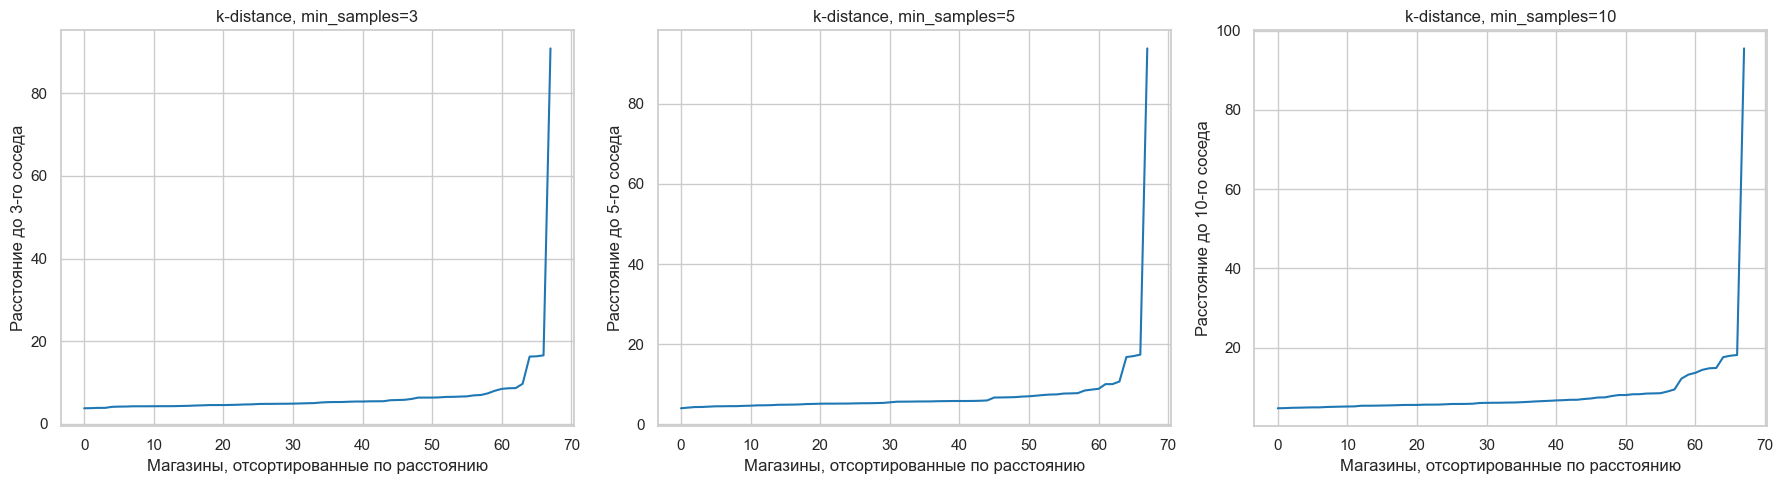

Кандидаты eps: [6.5986, 7.0055, 7.4213, 7.7416, 8.437, 8.5321, 9.1804, 9.4265, 13.8737, 13.9913, 14.6281, 16.6494]


In [28]:
min_samples_values = [3, 5, 10]
eps_candidates = set()

fig, axes = plt.subplots(1, len(min_samples_values), figsize=(18, 5))
for ax, min_samples in zip(axes, min_samples_values):
    nn = NearestNeighbors(n_neighbors=min_samples)
    nn.fit(X_main)
    distances, _ = nn.kneighbors(X_main)
    kth_distances = np.sort(distances[:, -1])
    ax.plot(kth_distances)
    ax.set_title(f'k-distance, min_samples={min_samples}')
    ax.set_xlabel('Магазины, отсортированные по расстоянию')
    ax.set_ylabel(f'Расстояние до {min_samples}-го соседа')

    for q in [0.80, 0.85, 0.90, 0.95]:
        eps_candidates.add(float(np.quantile(kth_distances, q)))

plt.tight_layout()
plt.show()

eps_values = sorted(round(x, 4) for x in eps_candidates if x > 0)
print('Кандидаты eps:', eps_values)

**Аналитический комментарий.** k-distance графики помогают подобрать `eps`: резкий изгиб кривой часто отделяет плотную основную массу магазинов от удалённых точек. Чем выше `eps`, тем меньше объектов будет признано шумом, но тем выше риск объединить разные сегменты. DBSCAN особенно полезен для поиска нетипичных магазинов, а не всегда для основной бизнес-сегментации.

In [29]:
dbscan_rows = []
dbscan_labels = {}
for min_samples in min_samples_values:
    for eps in eps_values:
        labels = DBSCAN(eps=eps, min_samples=min_samples).fit_predict(X_main)
        row = evaluate_clustering(X_main, labels, 'DBSCAN', {'eps': eps, 'min_samples': min_samples})
        row['Noise share'] = row['Noise points'] / len(store_features)
        dbscan_rows.append(row)
        dbscan_labels[(eps, min_samples)] = labels

dbscan_metrics = pd.DataFrame(dbscan_rows)
display(dbscan_metrics.sort_values(['Silhouette', 'Noise share'], ascending=[False, True]).head(20))

,Algorithm,Parameters,Clusters,Noise points,Silhouette,Calinski-Harabasz,Davies-Bouldin,Comment,Noise share
0,DBSCAN,"{'eps': 6.5986, 'min_samples': 3}",2,10,0.500139,17.501102,0.646546,Метрики рассчитаны по точкам без шума.,0.147059
16,DBSCAN,"{'eps': 8.437, 'min_samples': 5}",2,5,0.494927,26.527488,0.751865,Метрики рассчитаны по точкам без шума.,0.073529
17,DBSCAN,"{'eps': 8.5321, 'min_samples': 5}",2,5,0.494927,26.527488,0.751865,Метрики рассчитаны по точкам без шума.,0.073529
1,DBSCAN,"{'eps': 7.0055, 'min_samples': 3}",2,7,0.490393,16.832240,0.657555,Метрики рассчитаны по точкам без шума.,0.102941
2,DBSCAN,"{'eps': 7.4213, 'min_samples': 3}",2,7,0.490393,16.832240,0.657555,Метрики рассчитаны по точкам без шума.,0.102941
3,DBSCAN,"{'eps': 7.7416, 'min_samples': 3}",2,7,0.490393,16.832240,0.657555,Метрики рассчитаны по точкам без шума.,0.102941
4,DBSCAN,"{'eps': 8.437, 'min_samples': 3}",2,4,0.485111,29.237938,0.810170,Метрики рассчитаны по точкам без шума.,0.058824
5,DBSCAN,"{'eps': 8.5321, 'min_samples': 3}",2,4,0.485111,29.237938,0.810170,Метрики рассчитаны по точкам без шума.,0.058824
6,DBSCAN,"{'eps': 9.1804, 'min_samples': 3}",2,4,0.485111,29.237938,0.810170,Метрики рассчитаны по точкам без шума.,0.058824
7,DBSCAN,"{'eps': 9.4265, 'min_samples': 3}",2,4,0.485111,29.237938,0.810170,Метрики рассчитаны по точкам без шума.,0.058824


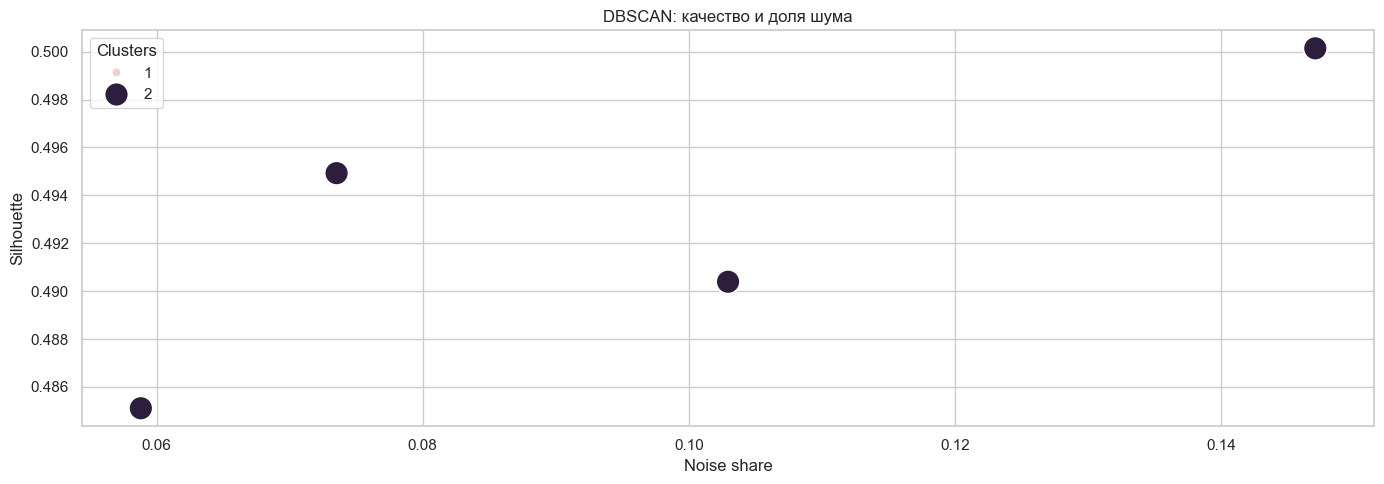

In [30]:
plt.figure(figsize=(14, 5))
plot_data = dbscan_metrics.copy()
plot_data['params'] = plot_data['Parameters']
sns.scatterplot(data=plot_data, x='Noise share', y='Silhouette', size='Clusters', hue='Clusters', sizes=(50, 300))
plt.title('DBSCAN: качество и доля шума')
plt.tight_layout()
plt.show()

**Аналитический комментарий.** На графике DBSCAN важно смотреть не только на Silhouette, но и на долю шума. Очень высокая доля шума означает, что алгоритм не столько сегментирует сеть, сколько выделяет небольшую плотную группу и считает остальные магазины нетипичными. Для управленческой сегментации такой результат может быть неудобен, но для поиска аномалий он полезен.

In [31]:
valid_dbscan = dbscan_metrics[(dbscan_metrics['Clusters'] >= 2) & (dbscan_metrics['Noise share'] <= 0.5)].copy()
if valid_dbscan.empty:
    best_dbscan_row = dbscan_metrics.sort_values(['Silhouette'], ascending=False).iloc[0]
else:
    best_dbscan_row = valid_dbscan.sort_values(['Silhouette', 'Noise share'], ascending=[False, True]).iloc[0]

best_dbscan_params = eval(best_dbscan_row['Parameters'])
best_dbscan_key = (best_dbscan_params['eps'], best_dbscan_params['min_samples'])
store_features['cluster_dbscan'] = dbscan_labels[best_dbscan_key]
print('Лучший вариант DBSCAN:', best_dbscan_key)
display(store_features['cluster_dbscan'].value_counts().sort_index().rename('stores_count'))

Лучший вариант DBSCAN: (6.5986, 3)


cluster_dbscan
-1    10
 0    55
 1     3
Name: stores_count, dtype: int64

## 16. Итоговая таблица метрик

In [32]:
best_hier_metrics = hier_metrics.sort_values(['Silhouette', 'Calinski-Harabasz'], ascending=[False, False]).head(1)
best_dbscan_metrics = pd.DataFrame([best_dbscan_row.to_dict()])
all_metrics = pd.concat([pd.DataFrame([kmeans_final_metrics]), best_hier_metrics, best_dbscan_metrics], ignore_index=True, sort=False)

metric_cols = ['Algorithm', 'Parameters', 'Clusters', 'Noise points', 'Silhouette', 'Calinski-Harabasz', 'Davies-Bouldin', 'Comment']
all_metrics = all_metrics[[c for c in metric_cols if c in all_metrics.columns]]
all_metrics.to_csv(METRICS_PATH, index=False, encoding='utf-8-sig')
print(f'Сохранено: {METRICS_PATH}')
display(all_metrics)

Сохранено: clustering_metrics_summary.csv


,Algorithm,Parameters,Clusters,Noise points,Silhouette,Calinski-Harabasz,Davies-Bouldin,Comment
0,KMeans,"{'k': 4, 'scaler': 'RobustScaler'}",4,0,0.236238,94.184904,1.127976,Метрики рассчитаны по всем магазинам.
1,AgglomerativeClustering,"{'linkage': 'ward', 'n_clusters': 2}",2,0,0.878715,142.284307,0.074793,Метрики рассчитаны по всем магазинам.
2,DBSCAN,"{'eps': 6.5986, 'min_samples': 3}",2,10,0.500139,17.501102,0.646546,Метрики рассчитаны по точкам без шума.


**Аналитический комментарий.** Итоговая таблица сопоставляет три семейства алгоритмов по одинаковым метрикам. k-means обычно удобнее всего объяснять бизнесу, иерархическая кластеризация помогает проверить вложенную структуру, а DBSCAN показывает нетипичные магазины через шумовые точки. Финальный выбор должен балансировать метрики, устойчивость и понятность сегментов.

## 17. PCA 2D и 3D

Доля объясненной дисперсии первых компонент: [0.70940381 0.0981413  0.0454167  0.03259579 0.02565594 0.01661008
 0.01229592 0.01000166 0.00664685 0.00519791]


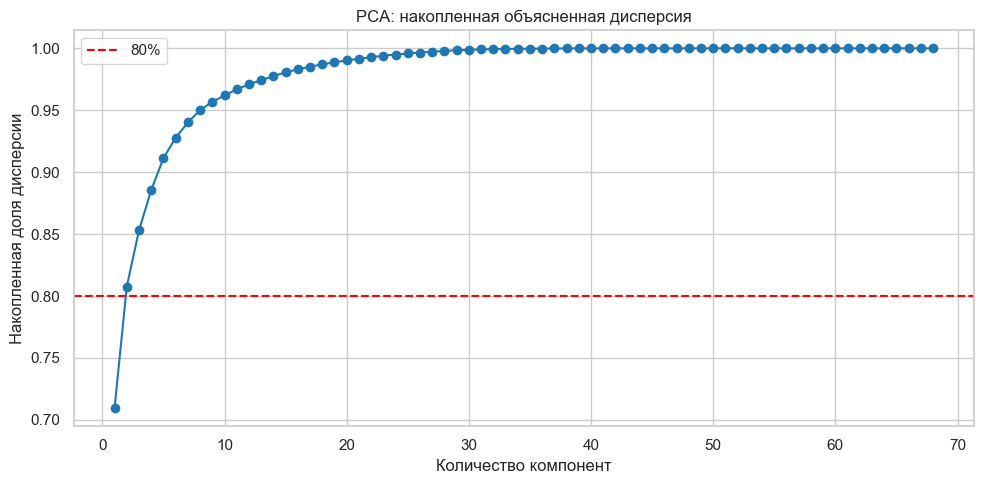

In [33]:
final_label_col = 'cluster_kmeans'
final_algorithm_name = 'KMeans'

pca_full = PCA(random_state=RANDOM_STATE)
pca_full.fit(X_main)
explained = pca_full.explained_variance_ratio_
print('Доля объясненной дисперсии первых компонент:', explained[:10])

plt.figure(figsize=(10, 5))
plt.plot(np.arange(1, len(explained) + 1), np.cumsum(explained), marker='o')
plt.axhline(0.8, color='red', linestyle='--', label='80%')
plt.title('PCA: накопленная объясненная дисперсия')
plt.xlabel('Количество компонент')
plt.ylabel('Накопленная доля дисперсии')
plt.legend()
plt.tight_layout()
plt.show()

**Аналитический комментарий.** График накопленной дисперсии показывает, какую часть информации из исходного признакового пространства сохраняют главные компоненты. Если первые две компоненты объясняют небольшую долю дисперсии, 2D-график следует воспринимать как удобную визуализацию, а не как полное доказательство качества кластеризации.

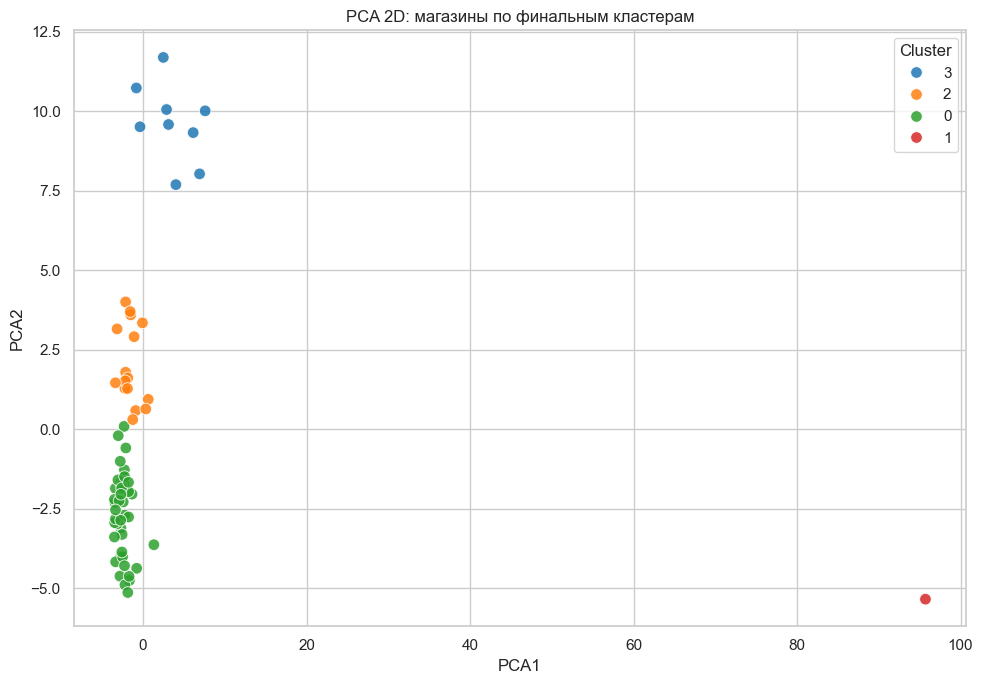

PCA 2D explained variance: [0.70940381 0.0981413 ]


In [34]:
pca_2 = PCA(n_components=2, random_state=RANDOM_STATE)
pca_3 = PCA(n_components=3, random_state=RANDOM_STATE)
X_pca_2 = pca_2.fit_transform(X_main)
X_pca_3 = pca_3.fit_transform(X_main)

plot_df = store_features[metadata_cols + absolute_features + [final_label_col]].copy()
plot_df['Cluster'] = plot_df[final_label_col].astype(str)
plot_df['PCA1'] = X_pca_2[:, 0]
plot_df['PCA2'] = X_pca_2[:, 1]

plt.figure(figsize=(10, 7))
sns.scatterplot(data=plot_df, x='PCA1', y='PCA2', hue='Cluster', s=70, alpha=0.85)
plt.title('PCA 2D: магазины по финальным кластерам')
plt.tight_layout()
plt.show()

print('PCA 2D explained variance:', pca_2.explained_variance_ratio_)

**Аналитический комментарий.** PCA 2D показывает расположение магазинов в двух наиболее информативных линейных направлениях. Хорошо отделённые облака подтверждают различия между сегментами, а зоны наложения указывают на пограничные магазины. Поскольку PCA линейный метод, он может не показать сложные нелинейные различия структуры спроса.

In [35]:
pca3_df = plot_df.copy()
pca3_df['Component1'] = X_pca_3[:, 0]
pca3_df['Component2'] = X_pca_3[:, 1]
pca3_df['Component3'] = X_pca_3[:, 2]
fig = px.scatter_3d(
    pca3_df,
    x='Component1', y='Component2', z='Component3',
    color='Cluster',
    hover_data=['ShopCode', 'City', 'Region', 'ShopFormat', 'sales_qty_total', 'revenue_total', 'unique_products_count'],
    title='PCA 3D: торговые точки по кластерам',
)
fig.show()

**Аналитический комментарий.** 3D-визуализация PCA добавляет третью компоненту и помогает увидеть разделение, которое может быть сжато на плоскости. Если кластеры расходятся в 3D лучше, чем в 2D, это означает, что часть различий между магазинами терялась при двумерной проекции.

## 18. t-SNE 2D и 3D

Допустимые perplexity: [5, 10]


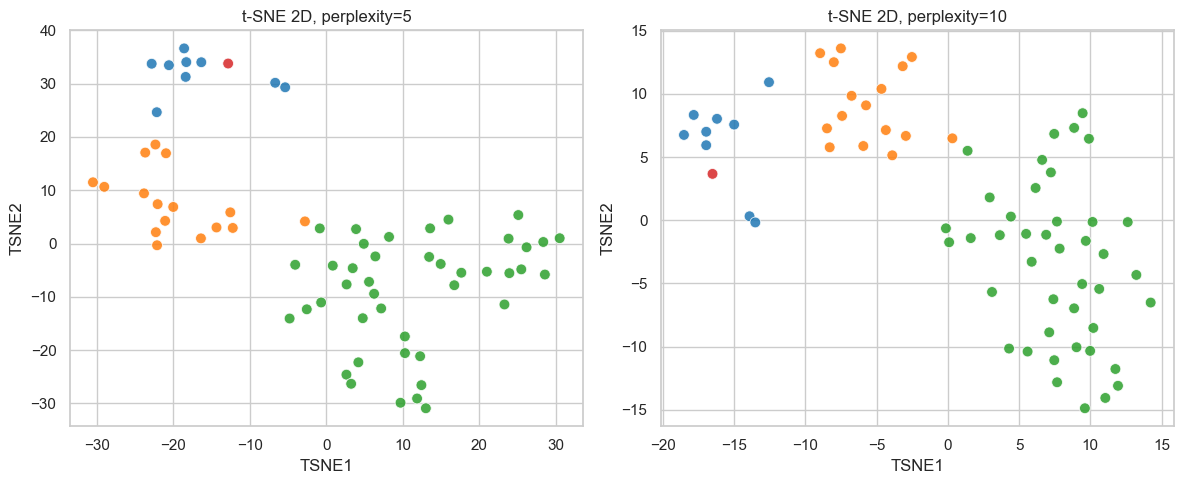

In [36]:
n_samples = len(store_features)
candidate_perplexities = [5, 10, 30, 50]
valid_perplexities = [p for p in candidate_perplexities if p < (n_samples - 1) / 3]
if not valid_perplexities:
    valid_perplexities = [max(2, min(5, n_samples - 2))]
print('Допустимые perplexity:', valid_perplexities)

tsne_embeddings_2d = {}
for p in valid_perplexities:
    emb = TSNE(n_components=2, perplexity=p, random_state=RANDOM_STATE, init='pca', learning_rate='auto').fit_transform(X_main)
    tsne_embeddings_2d[p] = emb

fig, axes = plt.subplots(1, len(valid_perplexities), figsize=(6 * len(valid_perplexities), 5), squeeze=False)
for ax, p in zip(axes.ravel(), valid_perplexities):
    tmp = plot_df.copy()
    tmp['TSNE1'] = tsne_embeddings_2d[p][:, 0]
    tmp['TSNE2'] = tsne_embeddings_2d[p][:, 1]
    sns.scatterplot(data=tmp, x='TSNE1', y='TSNE2', hue='Cluster', s=60, alpha=0.85, ax=ax, legend=False)
    ax.set_title(f't-SNE 2D, perplexity={p}')
plt.tight_layout()
plt.show()

**Аналитический комментарий.** t-SNE подчёркивает локальное сходство магазинов, поэтому хорошо показывает компактные группы и пограничные точки. Однако t-SNE может визуально усиливать разделение даже там, где глобальные расстояния неустойчивы. Поэтому совпадение t-SNE-картинки с метками кластеров является дополнительным аргументом, но не единственным основанием выбора модели.

In [37]:
tsne_p = valid_perplexities[min(len(valid_perplexities) - 1, 1)]
X_tsne_3 = TSNE(n_components=3, perplexity=tsne_p, random_state=RANDOM_STATE, init='pca', learning_rate='auto').fit_transform(X_main)
tsne3_df = plot_df.copy()
tsne3_df['Component1'] = X_tsne_3[:, 0]
tsne3_df['Component2'] = X_tsne_3[:, 1]
tsne3_df['Component3'] = X_tsne_3[:, 2]
fig = px.scatter_3d(
    tsne3_df,
    x='Component1', y='Component2', z='Component3',
    color='Cluster',
    hover_data=['ShopCode', 'City', 'Region', 'ShopFormat', 'sales_qty_total', 'revenue_total', 'unique_products_count'],
    title=f't-SNE 3D: perplexity={tsne_p}',
)
fig.show()

**Аналитический комментарий.** t-SNE 3D полезен для поиска локальных соседств, которые не видны на двумерной карте. Если отдельные магазины находятся далеко от своих кластеров, их стоит проверить как потенциально нестандартные точки по ассортименту, цене или уровню продаж.

## 19. UMAP 2D и 3D

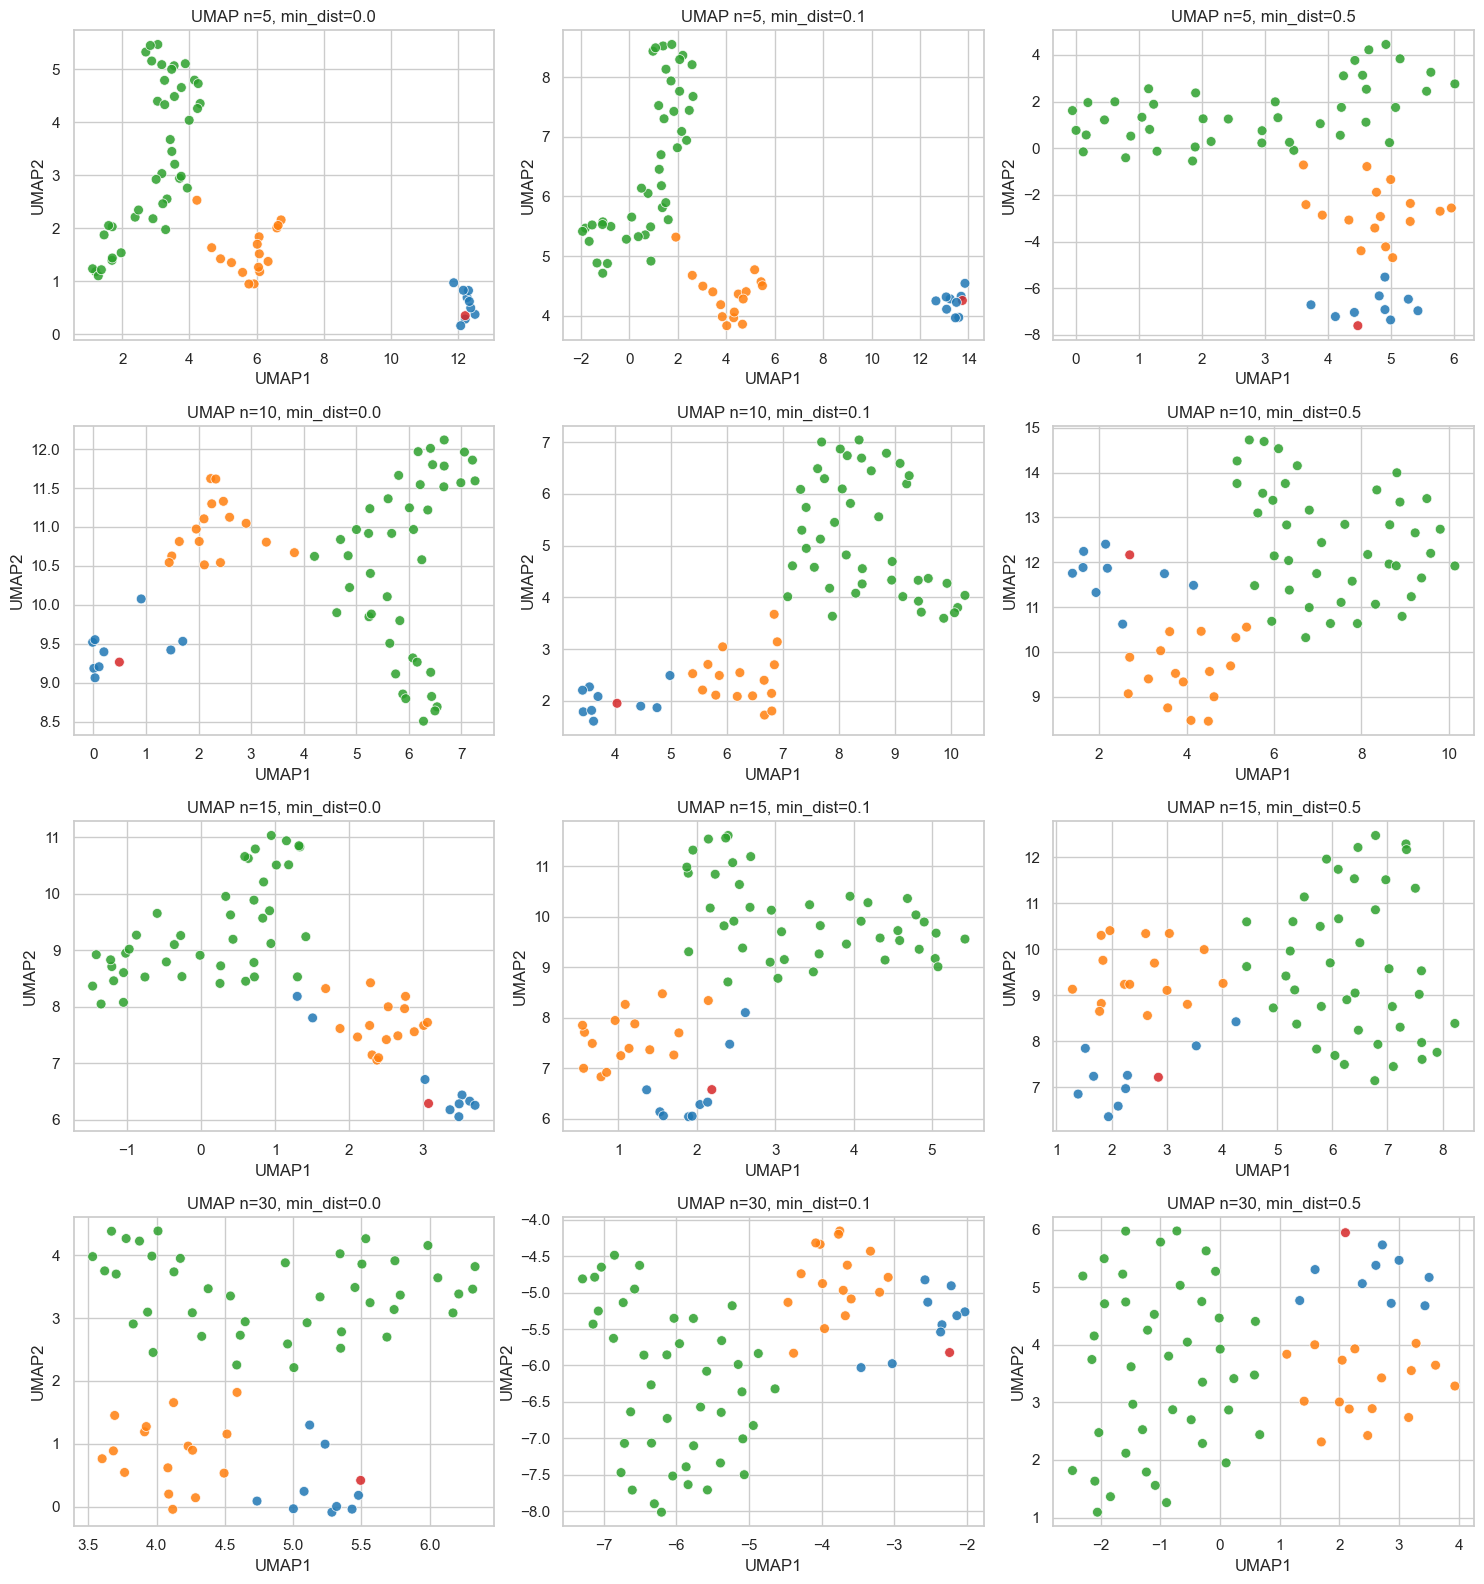

In [38]:
if UMAP_AVAILABLE:
    umap_results = {}
    n_neighbors_values = [v for v in [5, 10, 15, 30] if v < len(store_features)]
    min_dist_values = [0.0, 0.1, 0.5]

    fig, axes = plt.subplots(len(n_neighbors_values), len(min_dist_values), figsize=(5 * len(min_dist_values), 4 * len(n_neighbors_values)), squeeze=False)
    for i, n_neighbors in enumerate(n_neighbors_values):
        for j, min_dist in enumerate(min_dist_values):
            reducer = umap.UMAP(n_components=2, n_neighbors=n_neighbors, min_dist=min_dist, random_state=RANDOM_STATE)
            emb = reducer.fit_transform(X_main)
            umap_results[(n_neighbors, min_dist)] = emb
            tmp = plot_df.copy()
            tmp['UMAP1'] = emb[:, 0]
            tmp['UMAP2'] = emb[:, 1]
            sns.scatterplot(data=tmp, x='UMAP1', y='UMAP2', hue='Cluster', s=50, alpha=0.85, ax=axes[i, j], legend=False)
            axes[i, j].set_title(f'UMAP n={n_neighbors}, min_dist={min_dist}')
    plt.tight_layout()
    plt.show()
else:
    print('UMAP недоступен. Установите пакет umap-learn, чтобы выполнить этот раздел.')

**Аналитический комментарий.** UMAP обычно лучше сохраняет сочетание локальной и глобальной структуры, чем t-SNE, но результат зависит от `n_neighbors` и `min_dist`. Малые значения `min_dist` делают группы компактнее, а большие - показывают более плавные переходы между сегментами. Магазины между облаками можно рассматривать как пограничные для ценовой или ассортиментной политики.

In [39]:
if UMAP_AVAILABLE:
    best_umap_neighbors = [v for v in [15, 10, 5, 30] if v < len(store_features)][0]
    best_umap_min_dist = 0.1
    X_umap_3 = umap.UMAP(n_components=3, n_neighbors=best_umap_neighbors, min_dist=best_umap_min_dist, random_state=RANDOM_STATE).fit_transform(X_main)
    umap3_df = plot_df.copy()
    umap3_df['Component1'] = X_umap_3[:, 0]
    umap3_df['Component2'] = X_umap_3[:, 1]
    umap3_df['Component3'] = X_umap_3[:, 2]
    fig = px.scatter_3d(
        umap3_df,
        x='Component1', y='Component2', z='Component3',
        color='Cluster',
        hover_data=['ShopCode', 'City', 'Region', 'ShopFormat', 'sales_qty_total', 'revenue_total', 'unique_products_count'],
        title=f'UMAP 3D: n_neighbors={best_umap_neighbors}, min_dist={best_umap_min_dist}',
    )
    fig.show()
else:
    print('UMAP 3D пропущен: пакет umap-learn не установлен.')

**Аналитический комментарий.** UMAP 3D помогает проверить, остаются ли сегменты разделёнными при добавлении третьего измерения. Если кластеры стабильны в PCA, t-SNE и UMAP, это усиливает уверенность в том, что группы отражают реальную структуру магазинов, а не только особенности одного метода визуализации.

## 20. Интерпретация кластеров

In [40]:
def top_join(series, n=5):
    return ', '.join(series.dropna().astype(str).value_counts().head(n).index)


cluster_profiles = store_features.groupby(final_label_col).agg(
    stores_count=('ShopCode', 'nunique'),
    stores_list=('ShopCode', lambda x: ', '.join(map(str, x.head(30))) + (' ...' if len(x) > 30 else '')),
    main_cities=('City', top_join),
    main_regions=('Region', top_join),
    main_shop_formats=('ShopFormat', top_join),
    mean_sales_qty=('sales_qty_total', 'mean'),
    mean_revenue=('revenue_total', 'mean'),
    mean_avg_unit_price=('avg_revenue_per_unit', 'mean'),
    mean_stock_level=('mean_stock_qty', 'mean'),
    mean_unique_products=('unique_products_count', 'mean'),
    mean_active_days=('active_days_count', 'mean'),
).reset_index().rename(columns={final_label_col: 'cluster'})

qty_price_cols = [c for c in store_features.columns if c.startswith('qty_share_price_')]
rev_price_cols = [c for c in store_features.columns if c.startswith('revenue_share_price_')]

cluster_price_qty = store_features.groupby(final_label_col)[qty_price_cols].mean()
cluster_price_rev = store_features.groupby(final_label_col)[rev_price_cols].mean()
cluster_profiles['dominant_price_segment_by_qty'] = cluster_price_qty.idxmax(axis=1).str.replace('qty_share_price_', '', regex=False).values
cluster_profiles['dominant_price_segment_by_revenue'] = cluster_price_rev.idxmax(axis=1).str.replace('revenue_share_price_', '', regex=False).values

cluster_profiles.to_csv(PROFILES_PATH, index=False, encoding='utf-8-sig')
print(f'Сохранено: {PROFILES_PATH}')
display(cluster_profiles)

Сохранено: cluster_profiles.csv


,cluster,stores_count,stores_list,main_cities,main_regions,main_shop_formats,mean_sales_qty,mean_revenue,mean_avg_unit_price,mean_stock_level,mean_unique_products,mean_active_days,dominant_price_segment_by_qty,dominant_price_segment_by_revenue
0,0,42,"1110, 2100, 2108, 2113, 2177, 2286, 2342, 2437...","Город-025, Город-021, Город-036, Город-016, Го...","Регион-004, Регион-005, Регион-003, Регион-007...","3, 2, 4, 5, 1",9082.02381,499394.877190,55.115169,9.013849,90.976190,183.976190,Низкий ценовой сегмент,Высокий ценовой сегмент
1,1,1,1170,Город-012,Регион-004,1,40.00000,1802.175650,45.054391,1.521739,2.000000,23.000000,Низкий ценовой сегмент,Низкий ценовой сегмент
2,2,16,"1101, 1124, 1129, 1161, 2126, 2184, 2449, 271,...","Город-021, Город-036, Город-026, Город-017, Го...","Регион-004, Регион-007, Регион-002","2, 3, 1",4866.75000,253537.395336,52.230489,9.764522,61.750000,183.437500,Низкий ценовой сегмент,Низкий ценовой сегмент
3,3,9,"103, 106, 1117, 1159, 187, 2107, 2112, 2175, 2176","Город-016, Город-034, Город-037, Город-024, Го...","Регион-002, Регион-008, Регион-006, Регион-005...","2, 0, 1",2135.00000,108130.783129,50.963777,8.883440,25.444444,160.111111,Низкий ценовой сегмент,Низкий ценовой сегмент


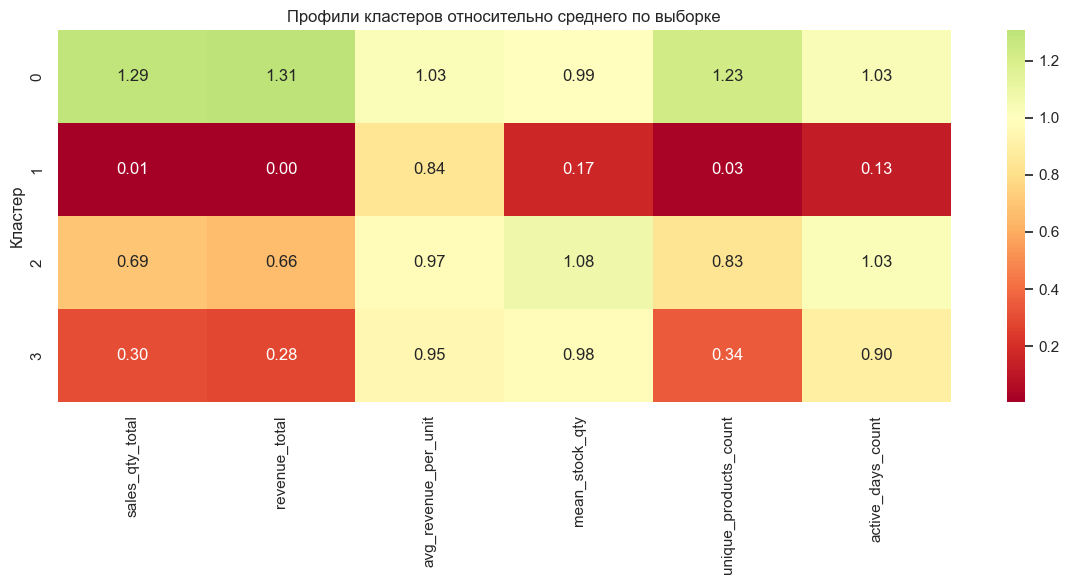

In [41]:
profile_features = ['sales_qty_total', 'revenue_total', 'avg_revenue_per_unit', 'mean_stock_qty', 'unique_products_count', 'active_days_count']
cluster_means = store_features.groupby(final_label_col)[profile_features].mean()
relative_profile = cluster_means / store_features[profile_features].mean()

plt.figure(figsize=(12, 6))
sns.heatmap(relative_profile, annot=True, cmap='RdYlGn', center=1, fmt='.2f')
plt.title('Профили кластеров относительно среднего по выборке')
plt.ylabel('Кластер')
plt.tight_layout()
plt.show()

**Аналитический комментарий.** Тепловая карта показывает, по каким характеристикам каждый кластер выше или ниже среднего уровня сети. Значения больше 1 означают превышение среднего, меньше 1 - отставание. Такой формат удобен для бизнес-интерпретации: он помогает отличить крупные магазины с широкой матрицей от небольших точек, магазины с высокой средней ценой от магазинов с более массовым спросом.

In [42]:
def relative_level(value, overall, high=1.15, low=0.85, words=('низкий', 'средний', 'высокий')):
    ratio = value / overall if overall else np.nan
    if pd.isna(ratio):
        return words[1]
    if ratio >= high:
        return words[2]
    if ratio <= low:
        return words[0]
    return words[1]


df_with_clusters = df_clean.merge(store_features[['ShopCode', final_label_col]], on='ShopCode', how='left')
product_by_cluster_qty = (
    df_with_clusters.groupby([final_label_col, 'ItemName'])['SalesQty'].sum()
    .sort_values(ascending=False)
    .groupby(level=0)
    .head(5)
)

overall_means = store_features[profile_features].mean()
for _, row in cluster_profiles.iterrows():
    cluster_id = row['cluster']
    qty_level = relative_level(row['mean_sales_qty'], overall_means['sales_qty_total'], words=('низкий', 'средний', 'высокий'))
    revenue_level = relative_level(row['mean_revenue'], overall_means['revenue_total'], words=('низкая', 'средняя', 'высокая'))
    assortment_level = relative_level(row['mean_unique_products'], overall_means['unique_products_count'], words=('ограниченный', 'средний', 'широкий'))
    price_level = relative_level(row['mean_avg_unit_price'], overall_means['avg_revenue_per_unit'], words=('низкая', 'средняя', 'высокая'))
    if cluster_id in product_by_cluster_qty.index.get_level_values(0):
        top_qty_names = ', '.join(product_by_cluster_qty.loc[cluster_id].index.get_level_values('ItemName')[:3])
    else:
        top_qty_names = 'нет данных'
    print(
        f"Кластер {cluster_id} включает {int(row['stores_count'])} торговых точек. "
        f"Для него характерны {qty_level} объем продаж, {revenue_level} выручка и {assortment_level} ассортимент. "
        f"Средняя цена относительно выборки: {price_level}. "
        f"Основной ценовой сегмент по количеству: {row['dominant_price_segment_by_qty']}; по выручке: {row['dominant_price_segment_by_revenue']}. "
        f"В структуре продаж выделяются товары: {top_qty_names}. "
        f"С точки зрения бизнеса этот кластер можно использовать для настройки ассортимента, запасов и ценовых решений отдельно от остальных групп."
    )

Кластер 0 включает 42 торговых точек. Для него характерны высокий объем продаж, высокая выручка и широкий ассортимент. Средняя цена относительно выборки: средняя. Основной ценовой сегмент по количеству: Низкий ценовой сегмент; по выручке: Высокий ценовой сегмент. В структуре продаж выделяются товары: Йогурт питьевой 90 г Растишка земляника 1,6% пл/бут, Биотворог 95г Тема Классический 4,5% пл/ст, Биотворог 95г Тема Клубника-банан 4% пл/ст. С точки зрения бизнеса этот кластер можно использовать для настройки ассортимента, запасов и ценовых решений отдельно от остальных групп.
Кластер 1 включает 1 торговых точек. Для него характерны низкий объем продаж, низкая выручка и ограниченный ассортимент. Средняя цена относительно выборки: низкая. Основной ценовой сегмент по количеству: Низкий ценовой сегмент; по выручке: Низкий ценовой сегмент. В структуре продаж выделяются товары: Продукт кисломолочный 95г Актимуно клубника-банан детский 1,5% п/бут, Продукт кисломолочный 95г Актимуно клубника-бан

## 21. Сравнение алгоритмов

In [43]:
comparison = pd.DataFrame({
    'Критерий': [
        'Нужно задавать число кластеров',
        'Удобство интерпретации',
        'Устойчивость к выбросам',
        'Поиск аномальных магазинов',
        'Бизнес-интерпретируемость',
        'Лучшие параметры',
        'Итоговая оценка',
    ],
    'k-means': [
        'Да',
        'Высокое',
        'Низкая-средняя',
        'Слабый',
        'Высокая',
        str({'k': final_k, 'scaler': best_scaler_name}),
        'Основной алгоритм для сегментации: простая интерпретация и понятные центры кластеров.',
    ],
    'Иерархическая кластеризация': [
        'Да',
        'Высокое',
        'Средняя',
        'Средний',
        'Высокая',
        str(best_hier_key),
        'Полезна для проверки вложенной структуры и устойчивости числа кластеров.',
    ],
    'DBSCAN': [
        'Нет',
        'Среднее',
        'Высокая',
        'Хороший',
        'Зависит от параметров',
        str(best_dbscan_key),
        'Лучше использовать как инструмент поиска нестандартных магазинов и шума.',
    ],
})
display(comparison)

,Критерий,k-means,Иерархическая кластеризация,DBSCAN
0,Нужно задавать число кластеров,Да,Да,Нет
1,Удобство интерпретации,Высокое,Высокое,Среднее
2,Устойчивость к выбросам,Низкая-средняя,Средняя,Высокая
3,Поиск аномальных магазинов,Слабый,Средний,Хороший
4,Бизнес-интерпретируемость,Высокая,Высокая,Зависит от параметров
5,Лучшие параметры,"{'k': 4, 'scaler': 'RobustScaler'}","('ward', 2)","(6.5986, 3)"
6,Итоговая оценка,Основной алгоритм для сегментации: простая инт...,Полезна для проверки вложенной структуры и уст...,Лучше использовать как инструмент поиска неста...


**Аналитический комментарий.** k-means выбран как основной алгоритм, потому что его результат легче перевести в управленческие сегменты: каждый магазин получает понятную группу, а профили кластеров можно сравнить по средним продажам, выручке, ассортименту и цене. Иерархическая кластеризация выступает как проверка структуры, DBSCAN - как дополнительный инструмент поиска нестандартных торговых точек.

## 22. Бизнес-рекомендации

1. Для кластеров с высокой выручкой и широким ассортиментом стоит поддерживать расширенную товарную матрицу и внимательно контролировать наличие ключевых SKU, потому что потери наличия в таких магазинах сильнее влияют на общий результат категории.
2. Для кластеров с низким объёмом продаж полезно проверить ассортиментную избыточность: часть товаров может создавать запас без достаточного спроса.
3. Для кластеров с высокой средней ценой можно тестировать премиальные позиции и анализировать чувствительность к акциям отдельно от массовых магазинов.
4. Для кластеров с доминированием низкого ценового сегмента рекомендуется фокус на базовой линейке, стабильности остатков и промо-механиках с понятной ценой.
5. Магазины, отмеченные DBSCAN как шум, стоит разобрать отдельно: они могут быть аномальными по формату, городу, запасам, ассортименту или качеству данных.
6. Результаты можно использовать для дифференцированного планирования запасов, настройки промо, выбора глубины ассортимента и сравнения магазинов только с похожими торговыми точками.

## 23. Ограничения анализа

1. Анализ проводится только по одной товарной категории - «Детская молочная продукция», поэтому результаты нельзя автоматически переносить на всю розничную сеть.
2. В данных отсутствует реальная маржинальность, поэтому экономические выводы ограничены выручкой, количеством продаж и уровнем цены.
3. Ценовые сегменты сформированы искусственно на основе средней цены товара, а не взяты из коммерческого справочника.
4. Запасы могут быть представлены как снимки состояния, поэтому их интерпретация требует осторожности; сумма запасов не используется как показатель оборота.
5. Кластеризация является исследовательским методом и не доказывает причинно-следственные связи.
6. Качество результата зависит от периода июль-декабрь 2024 года; сезонность и промо могут влиять на сегменты.
7. География и формат магазина использованы для интерпретации, но не включены в основную матрицу признаков как категориальные переменные.

## 24. Итоговые выводы

1. Основным алгоритмом для бизнес-сегментации выбран **k-means**, так как он даёт понятные и воспроизводимые группы магазинов.
2. Оптимальное количество кластеров выбирается по балансу метода локтя, Silhouette, Calinski-Harabasz, Davies-Bouldin и интерпретируемости профилей.
3. Иерархическая кластеризация используется для проверки естественной структуры данных и сопоставления с k-means.
4. DBSCAN полезен прежде всего для поиска нетипичных магазинов: шумовые точки требуют отдельной проверки бизнеса и качества данных.
5. Найденные кластеры отличаются масштабом продаж, выручкой, шириной ассортимента, уровнем запасов и ценовой структурой спроса.
6. Типичные представители кластеров можно искать как магазины, расположенные близко к средним значениям своего кластера; пограничные и шумовые точки требуют отдельного анализа.
7. Для ценообразования результаты позволяют различать магазины с высокой, средней и низкой ценовой ориентацией внутри категории.
8. Для управления ассортиментом результаты помогают разделить магазины, где нужна широкая матрица, и магазины, где рациональнее держать компактный набор наиболее востребованных товаров.
9. В следующей версии исследования полезно добавить маржу, промо-признаки, площадь магазина, трафик, реальные ценовые сегменты, признак наличия товара на полке и данные по другим категориям.
10. Итоговая сегментация должна использоваться как аналитическая поддержка решений, а не как автоматическое правило без проверки категорийным менеджером.